# Setup

In [1]:
!pip install torchsummary
!pip install torchmetrics
!pip install git+https://github.com/fangwei123456/spikingjelly.git

  Cloning https://github.com/fangwei123456/spikingjelly.git to /tmp/pip-req-build-u6q7mzio
  Running command git clone --filter=blob:none --quiet https://github.com/fangwei123456/spikingjelly.git /tmp/pip-req-build-u6q7mzio
  Resolved https://github.com/fangwei123456/spikingjelly.git to commit 8884ac94ab1dc2deb2300a46252b21cef50a3922
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for spikingjelly: filename=spikingjelly-2.0.0-py3-none-any.whl size=996649 sha256=7e8f24c08de71c91bb3f31594389344a98dc19c356f7e3b5ccc4abab9accaadc
  Stored in directory: /tmp/pip-ephem-wheel-cache-3i97fz8b/wheels/93/ab/c9/e0318e4c9feaebc1632bcc0168638a2ed5ef17340741c9ad49
Successfully built spikingjelly


In [2]:
%matplotlib inline

# import
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import numpy as np
from torchsummary import summary # Libraries for previewing neural network architectures
from spikingjelly.activation_based import neuron, encoding, functional, surrogate
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import time

In [3]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.optim import Optimizer, Adam, AdamW, SGD
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import timm
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import  ImageFolder
from collections import Counter
from torchvision.transforms import ToTensor
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score


In [4]:
!python -m pip uninstall -y snn-bench


In [5]:
!pip install snn-bench --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 2.4 MB/s eta 0:00:00a 0:00:01


In [6]:
import snn_bench
from snn_bench import models, config

In [7]:
train_loader, val_loader, test_loader, meta = snn_bench.data.get_loaders(name='kmnist')

100%|██████████| 9.91M/9.91M [00:00<00:00, 28.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.12MB/s]


In [9]:
train_loader.dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [10]:
train_dataset, val_dataset, test_dataset = train_loader.dataset, val_loader.dataset, test_loader.dataset

In [11]:
NUM_CLASSES  = meta.num_classes
CLASS_NAMES  = train_loader.dataset.classes
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train: 60000 | Val: 5000 | Test: 5000


In [12]:
cfg = config.Config(NUM_CLASSES, CLASS_NAMES, "./model_save/checkpoints")

# ANN

In [13]:
ann = models.ann.ANN(NUM_CLASSES)


In [14]:
from snn_bench.train import train_ann



  Training: ANN

  Training from scratch: no backbone(base_model) to freeze


  Epoch 1/30 | train_loss=2.0874 | train_acc=0.4673 | val=1.5900 | val_acc=0.706
{'epoch': 1, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 2.0874078273773193, 'train_acc': 0.4672642946243286, 'val_loss': 1.5900026559829712, 'val_acc': 0.7059999704360962, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 2/30 | train_loss=1.3334 | train_acc=0.7237 | val=1.0601 | val_acc=0.835
{'epoch': 2, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.3333579301834106, 'train_acc': 0.7237246036529541, 'val_loss': 1.0601167678833008, 'val_acc': 0.8345999717712402, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 3/30 | train_loss=1.0459 | train_acc=0.8157 | val=0.9139 | val_acc=0.883
{'epoch': 3, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.0459132194519043, 'train_acc': 0.8156550526618958, 'val_loss': 0.9138548970222473, 'val_acc': 0.883400022983551, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 4/30 | train_loss=0.9308 | train_acc=0.8624 | val=0.8366 | val_acc=0.905
{'epoch': 4, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.9308386445045471, 'train_acc': 0.8624466061592102, 'val_loss': 0.8365674614906311, 'val_acc': 0.9047999978065491, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


...

  Epoch 26/30 | train_loss=0.5968 | train_acc=0.9782 | val=0.5730 | val_acc=0.984
{'epoch': 26, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5967985987663269, 'train_acc': 0.978181779384613, 'val_loss': 0.5729947686195374, 'val_acc': 0.9837999939918518, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 27/30 | train_loss=0.5939 | train_acc=0.9790 | val=0.5712 | val_acc=0.984
{'epoch': 27, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5938997268676758, 'train_acc': 0.9789830446243286, 'val_loss': 0.571189284324646, 'val_acc': 0.9842000007629395, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 28/30 | train_loss=0.5917 | train_acc=0.9790 | val=0.5689 | val_acc=0.985
{'epoch': 28, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5917107462882996, 'train_acc': 0.9789997339248657, 'val_loss': 0.5689115524291992, 'val_acc': 0.9846000075340271, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 29/30 | train_loss=0.5893 | train_acc=0.9800 | val=0.5667 | val_acc=0.985
{'epoch': 29, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5892659425735474, 'train_acc': 0.9800347089767456, 'val_loss': 0.5667007565498352, 'val_acc': 0.9850000143051147, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 30/30 | train_loss=0.5865 | train_acc=0.9806 | val=0.5649 | val_acc=0.985
{'epoch': 30, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5865378379821777, 'train_acc': 0.9806190133094788, 'val_loss': 0.5648783445358276, 'val_acc': 0.9851999878883362, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved
  ✔✔ Best checkpoint loaded: val_loss=0.5649


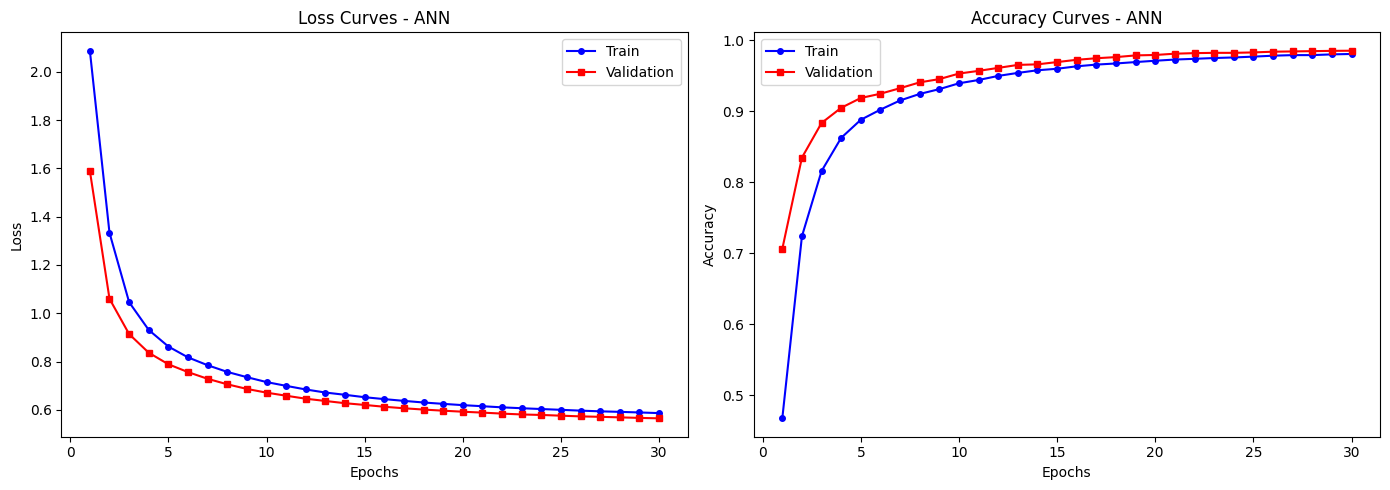


───────────────────────────────────────────────────────
  ANN
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.972     0.993     0.982       451
           1      0.989     0.996     0.993       553
           2      0.972     0.976     0.974       495
           3      0.976     0.983     0.979       530
           4      0.990     0.978     0.984       501
           5      0.991     0.984     0.988       449
           6      0.987     0.978     0.983       460
           7      0.981     0.983     0.982       531
           8      0.976     0.980     0.978       508
           9      0.982     0.964     0.973       522

    accuracy                          0.982      5000
   macro avg      0.982     0.982     0.982      5000
weighted avg      0.982     0.982     0.982      5000

  Macro F1: 0.9816

  Confusion Matrix: tensor([[448,   0,   0,   0,   0,   0,   1,   1,   1,   0],
        [  0, 551,   2

In [15]:
#options = train_ann.TrainOptions.get_default()

ann_history_results, ann_evaluation_results, ann_results = train_ann.start_training_ann_loop(ann, train_loader, val_loader, test_loader, cfg)

In [16]:
from snn_bench.evaluate import eval_ann


  Confusion Matrix: ANN


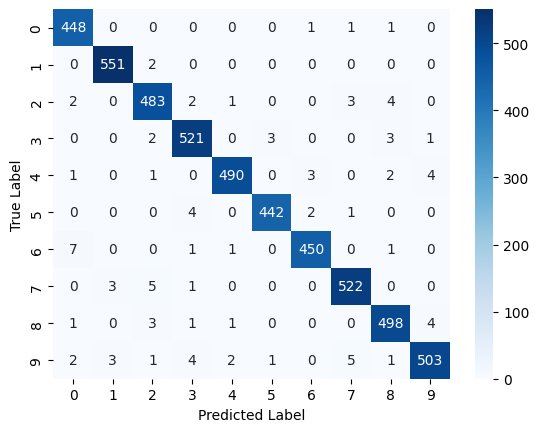

In [17]:
for model_name, er in ann_evaluation_results.items():
  print(f"\n{'='*60}")
  print(f"  Confusion Matrix: {model_name}")
  print(f"{'='*60}")
  eval_ann.plot_confusion_matrix(er, model_name, cfg)


True label: 3
Predicted label: 3


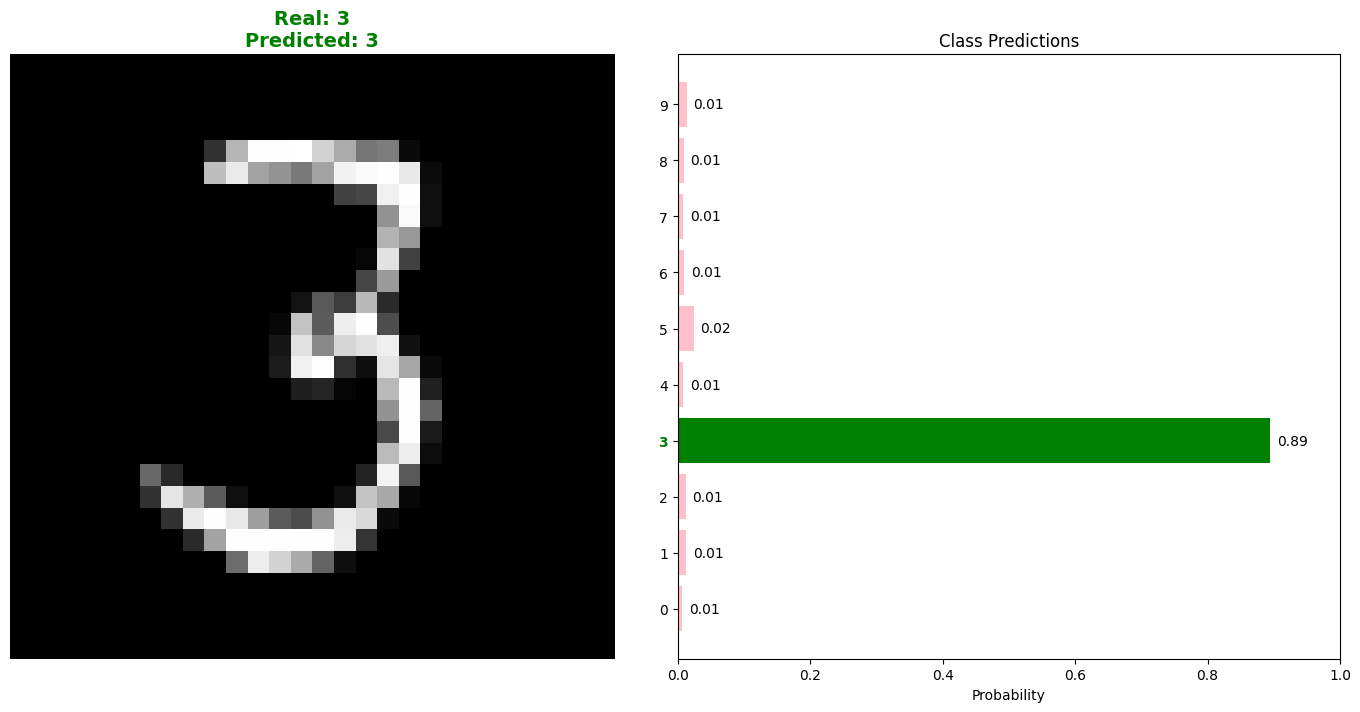

In [18]:
eval_ann.test_eval(ann, 4373, test_dataset, cfg)

# SNN

In [19]:
snn = models.snn.SNN()
snn.to(cfg.device)

SNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_1): Linear(in_features=784, out_features=10, bias=False)
  (lif_layer_1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
)

In [20]:
from snn_bench.train import train_snn

In [21]:
snn_options = train_snn.TrainOptions.get_default_none()

loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store, epoch = train_snn.start_training_snn_loop(snn, train_loader, test_loader, cfg, snn_options)

----------- 0 round of training begins------------
loss train:  0.0324, accuracy rate train:  83.5733%, loss cv:  0.0223, accuracy rate cv:  89.5800%
----------- 1 round of training begins------------
loss train:  0.0204, accuracy rate train:  90.1700%, loss cv:  0.0195, accuracy rate cv:  90.7400%
----------- 2 round of training begins------------
loss train:  0.0188, accuracy rate train:  90.8150%, loss cv:  0.0189, accuracy rate cv:  90.6400%
----------- 3 round of training begins------------
loss train:  0.0179, accuracy rate train:  91.1383%, loss cv:  0.0184, accuracy rate cv:  90.8600%
----------- 4 round of training begins------------
loss train:  0.0173, accuracy rate train:  91.4083%, loss cv:  0.0178, accuracy rate cv:  91.2200%
-------------------------------Training Complete-------------------------------


In [22]:
from snn_bench.evaluate import eval_snn

---------Graph showing how the loss function changes over training epochs---------


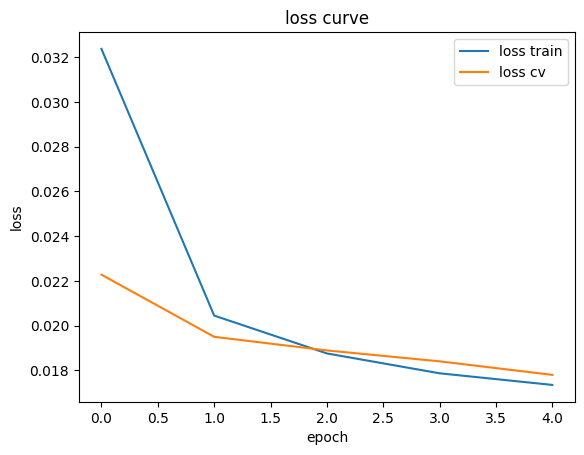

---------Graph showing how accuracy changes over training epochs---------


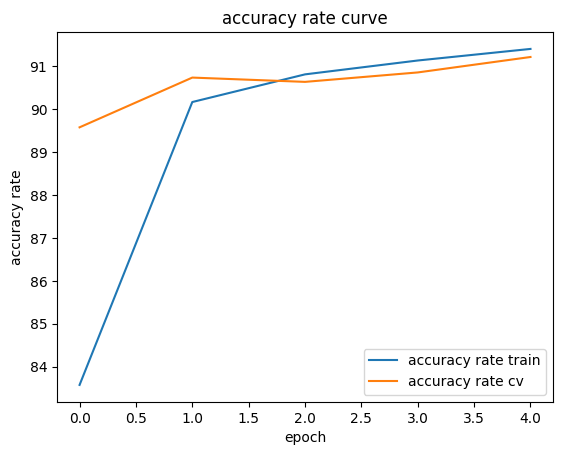

In [23]:
eval_snn.plot_loss_curves(epoch, loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store)

Original image
label: 7


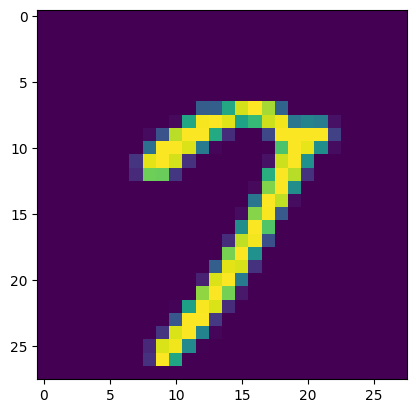

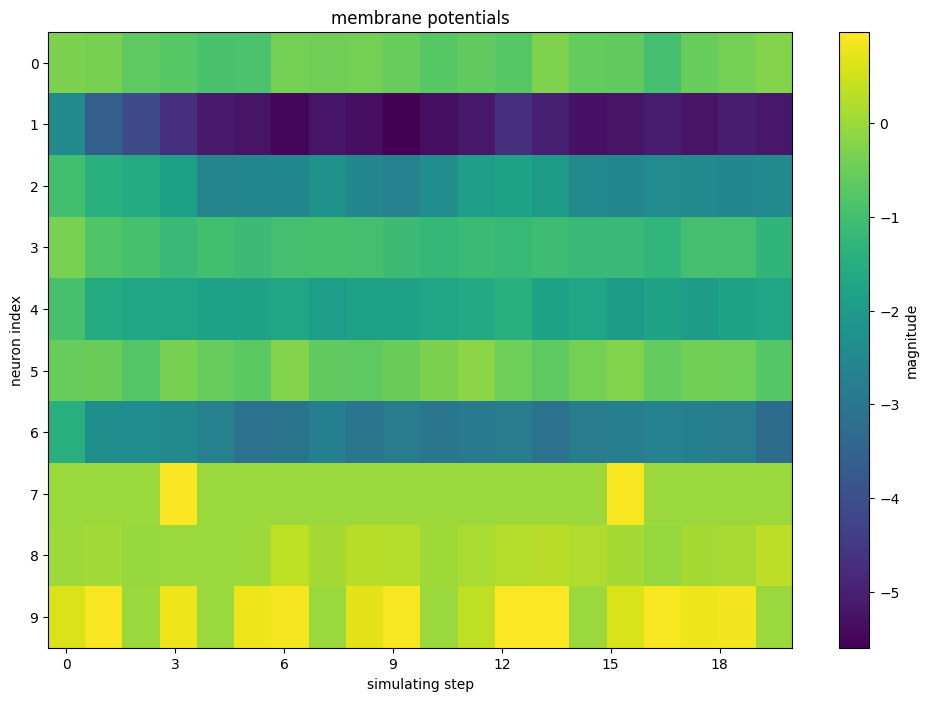

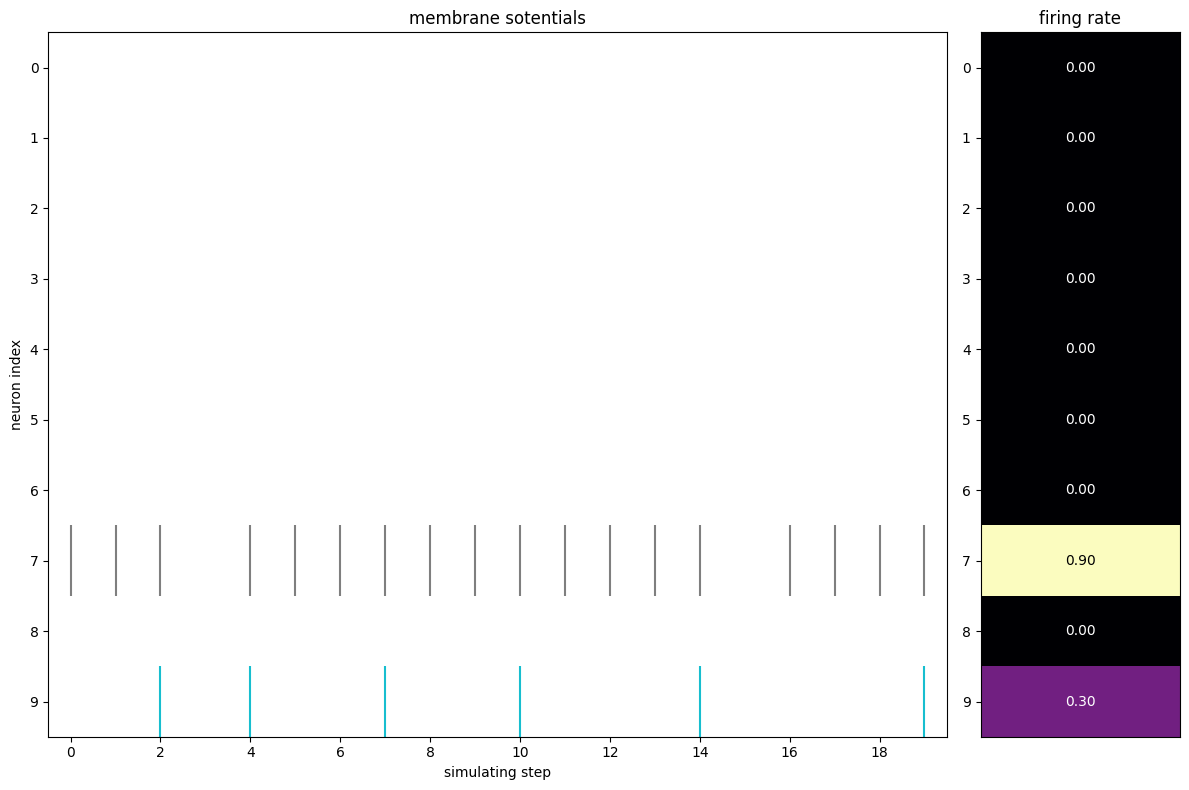

In [24]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.lif_layer_1 # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 3373
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

encoder = snn_options = train_snn.TrainOptions.get_default().encoder
T = 20
# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(cfg.device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

In [25]:
snn = models.snn.DirectSNN(NUM_CLASSES)
snn.to(cfg.device)

DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=Fals

In [58]:
snn_options = train_snn.TrainOptions.get_default_none()

loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store, epoch = train_snn.start_training_snn_loop(snn, train_loader, test_loader, cfg, snn_options)

----------- 0 round of training begins------------
loss train:  0.0014, accuracy rate train:  99.1783%, loss cv:  0.0080, accuracy rate cv:  95.0800%
----------- 1 round of training begins------------
loss train:  0.0009, accuracy rate train:  99.4550%, loss cv:  0.0076, accuracy rate cv:  95.5200%
----------- 2 round of training begins------------
loss train:  0.0007, accuracy rate train:  99.5517%, loss cv:  0.0073, accuracy rate cv:  95.2600%
----------- 3 round of training begins------------
loss train:  0.0005, accuracy rate train:  99.6450%, loss cv:  0.0069, accuracy rate cv:  95.9400%
----------- 4 round of training begins------------
loss train:  0.0004, accuracy rate train:  99.7067%, loss cv:  0.0066, accuracy rate cv:  95.9000%
-------------------------------Training Complete-------------------------------


---------Graph showing how the loss function changes over training epochs---------


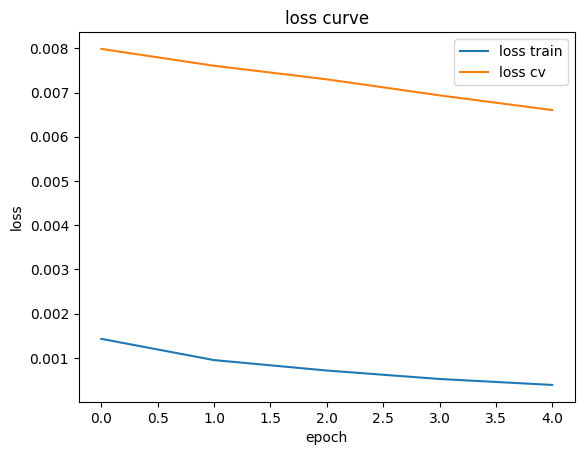

---------Graph showing how accuracy changes over training epochs---------


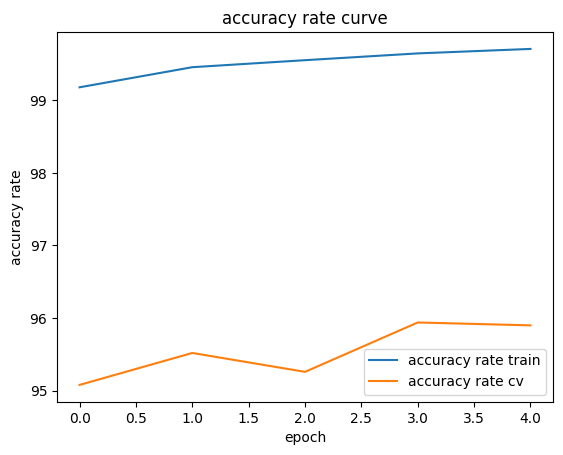

In [59]:
eval_snn.plot_loss_curves(epoch, loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store)

Original image
label: 1


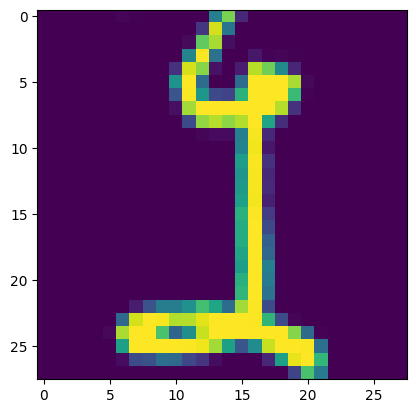

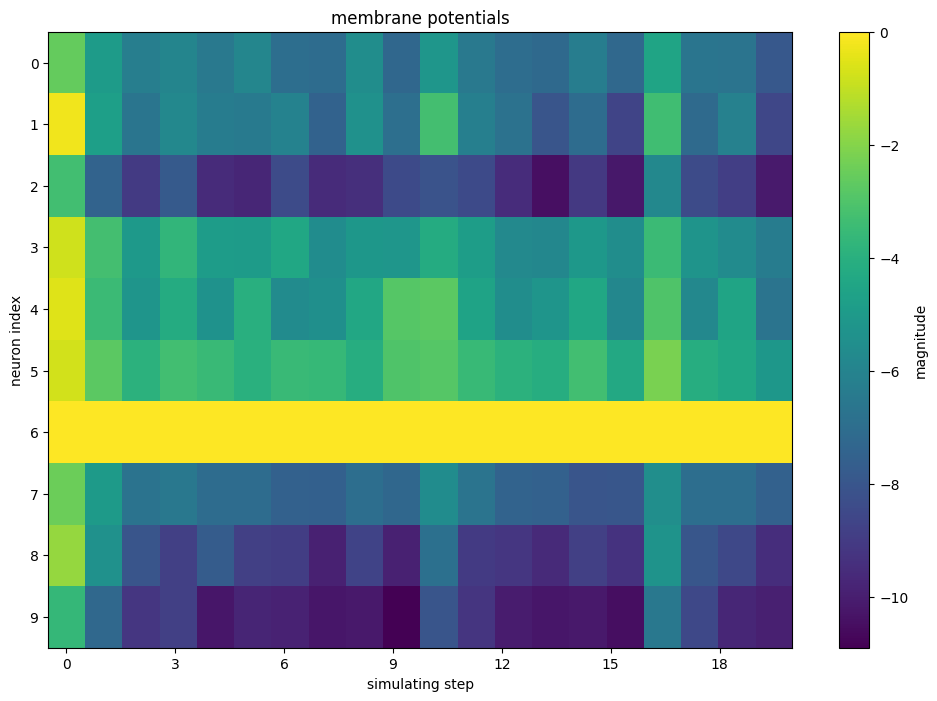

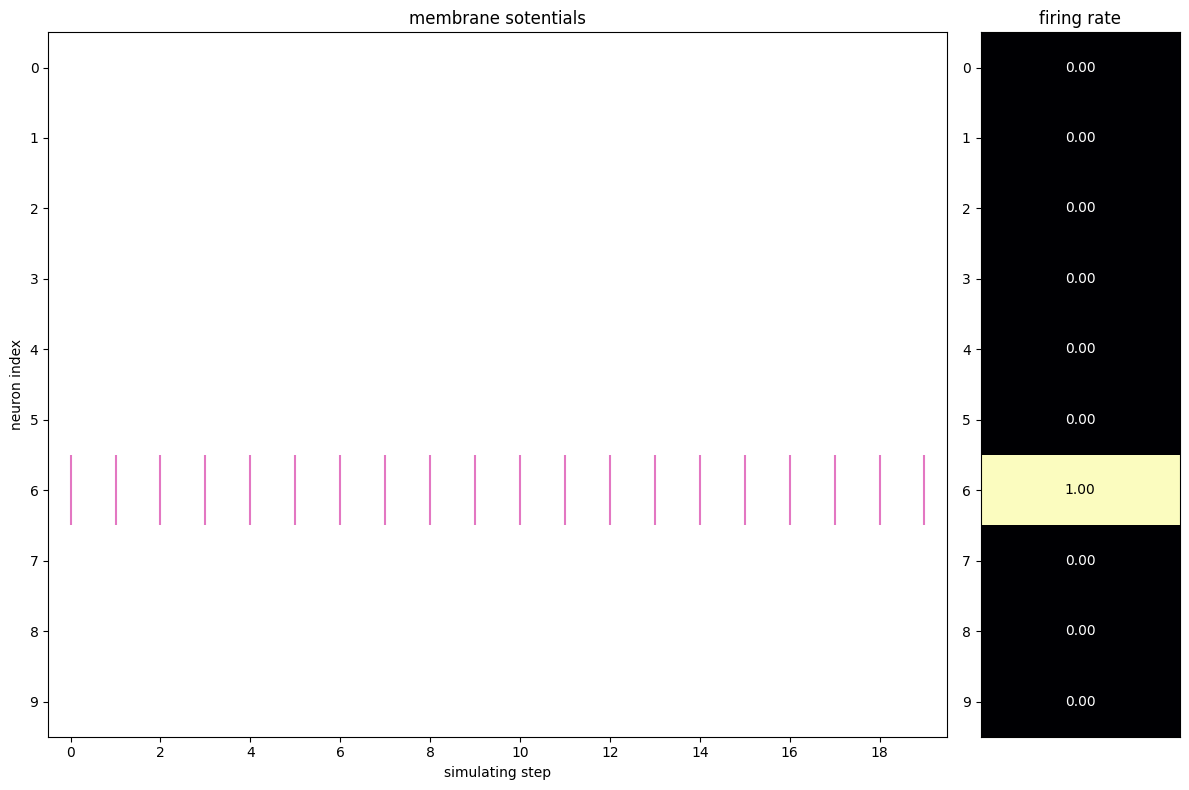

In [60]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.classifier[6] # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 345
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

encoder = snn_options = train_snn.TrainOptions.get_default().encoder
T = 20
# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(cfg.device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

Original image
label: 5


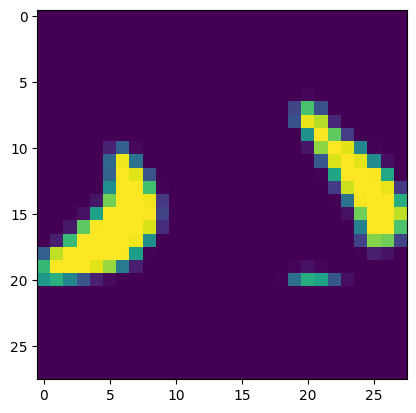

Unexpected err=RuntimeError('mat1 and mat2 shapes cannot be multiplied (64x49 and 3136x512)'), type(err)=<class 'RuntimeError'>


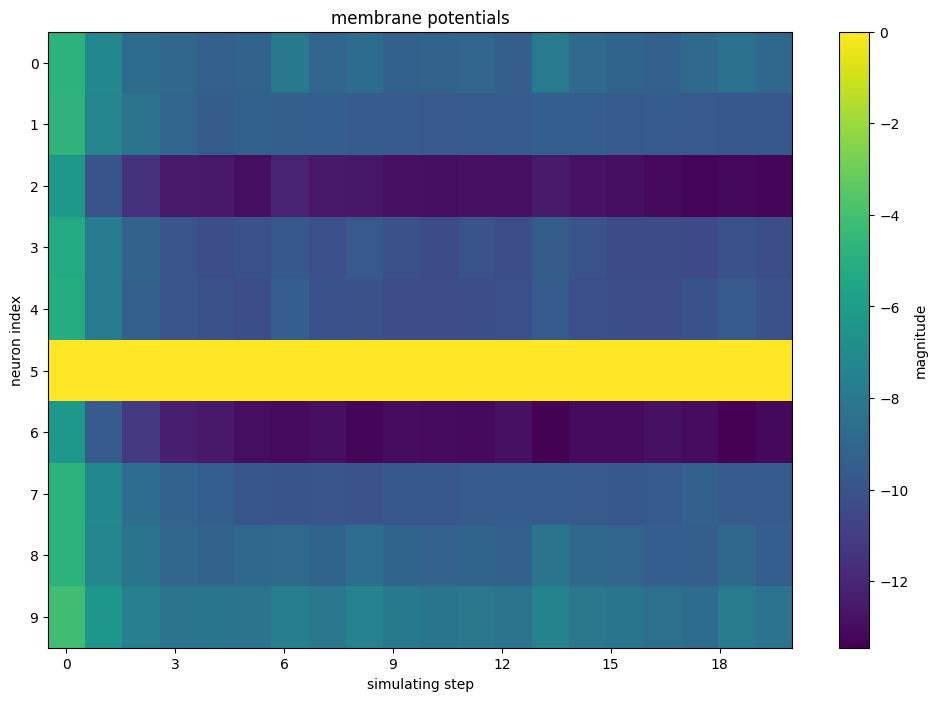

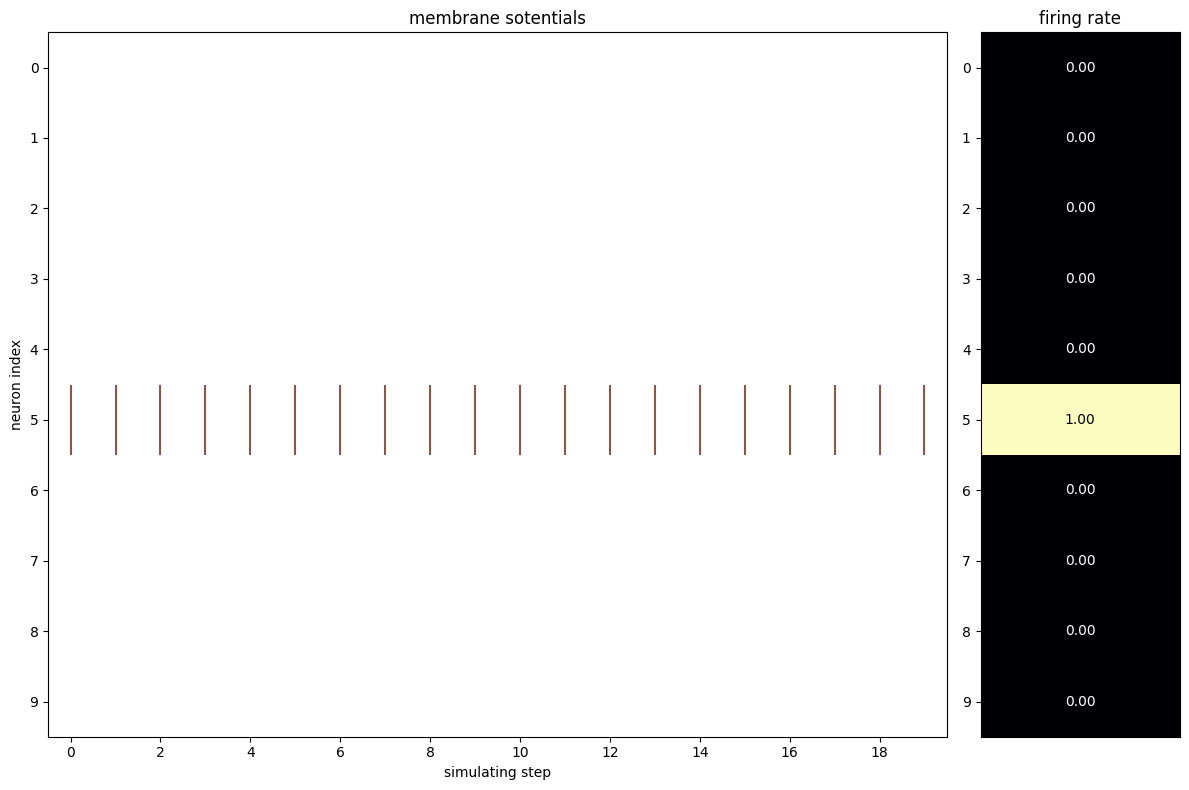

In [61]:
from spikingjelly.activation_based import neuron, encoding, functional, surrogate


eval_snn.plot_snn_module_spikes(snn, test_dataset, encoding.PoissonEncoder(), cfg, 798)

# ANN2SNN

In [62]:
from snn_bench.conversion import Converter
import snn_bench.conversion_mod.recipes as snn_bench_recipes

In [63]:
conv_snn_max = Converter.handle_rate_coded(ann, train_dataset, cfg)

100%|██████████| 469/469 [00:12<00:00, 37.86it/s]


In [64]:
conv_snn_max

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.544692, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.835901, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.285609, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [65]:
conv_snn_99 =  Converter.handle_rate_coded(ann, train_dataset, cfg, mode="99.9%")

100%|██████████| 469/469 [00:12<00:00, 36.35it/s]


In [66]:
conv_snn_99

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.623225, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.604557, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.347890, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [67]:
conv_snn_balanced = Converter.handle_rate_coded_threshold_balanced(ann, train_dataset, cfg)

100%|██████████| 469/469 [00:12<00:00, 36.33it/s]


In [68]:
conv_snn_half =  Converter.handle_rate_coded(ann, train_dataset, cfg, mode=1.0/2)

100%|██████████| 469/469 [00:12<00:00, 37.97it/s]


In [69]:
from snn_bench.evaluate import eval_snn

In [70]:
curve_max  = eval_snn.accuracy_vs_T(conv_snn_max,  test_loader, T_max=64, device=cfg.device)
curve_99 = eval_snn.accuracy_vs_T(conv_snn_99, test_loader, T_max=64, device=cfg.device)
curve_half = eval_snn.accuracy_vs_T(conv_snn_half, test_loader, T_max=64, device=cfg.device)
curve_balanced = eval_snn.accuracy_vs_T(conv_snn_balanced, test_loader, T_max=64, device=cfg.device)
curve_base_snn = eval_snn.accuracy_vs_T(snn, test_loader, T_max=64, device=cfg.device)

In [71]:
ann_results['ANN'].accuracy

0.8992000222206116

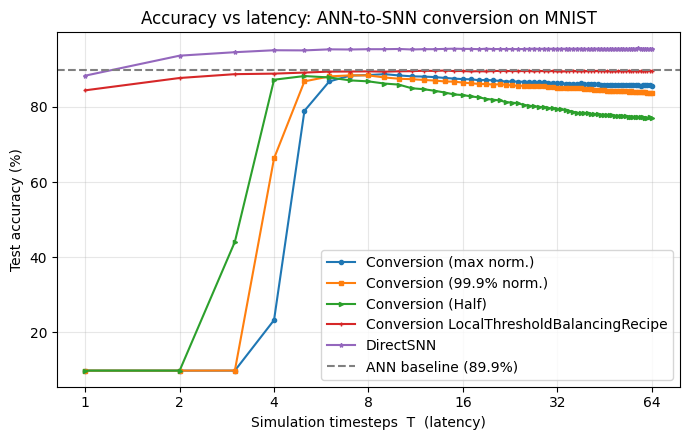

In [72]:
eval_snn.plot_accuracy_vs_T(ann_results['ANN'].accuracy, 64, [
    {"y": curve_max, "marker": "o", "ms": 3, "label": "Conversion (max norm.)"},
    {"y": curve_99,  "marker": "s", "ms": 3, "label": "Conversion (99.9% norm.)"},
    {"y": curve_half,  "marker": ">", "ms": 3, "label": "Conversion (Half)"},
    {"y": curve_balanced,  "marker": "+", "ms": 3, "label": "Conversion LocalThresholdBalancingRecipe"},
    {"y": curve_base_snn, "marker": "*", "ms": 3, "label": "DirectSNN"},
])

In [73]:
from snn_bench.conversion import eval_conv_snn

Original label: 9


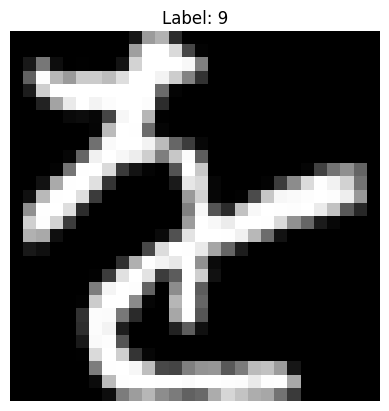

Predicted class (rate coding, T=16): 9


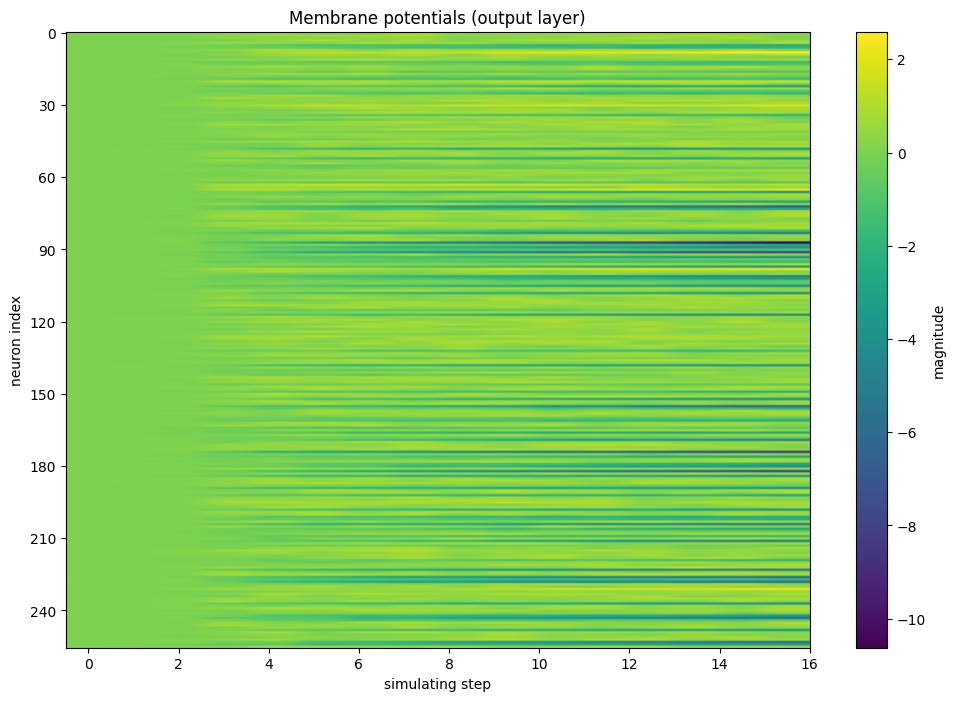

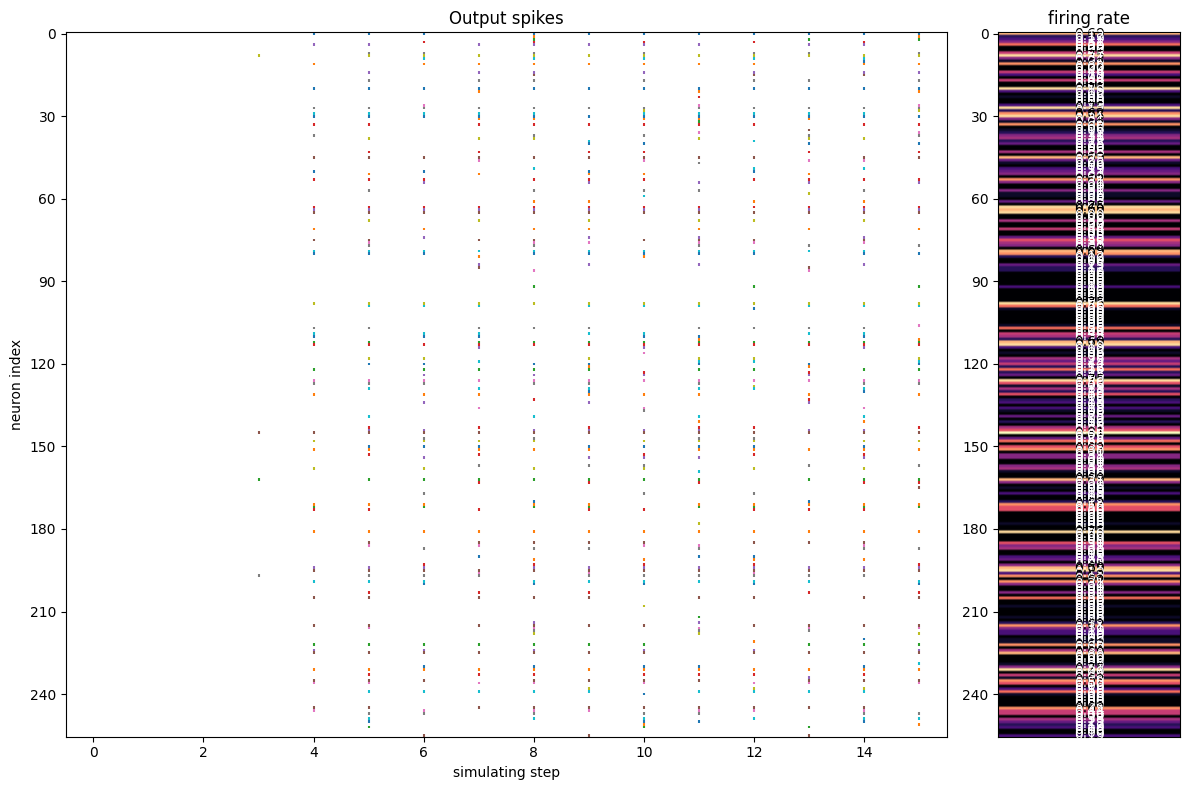

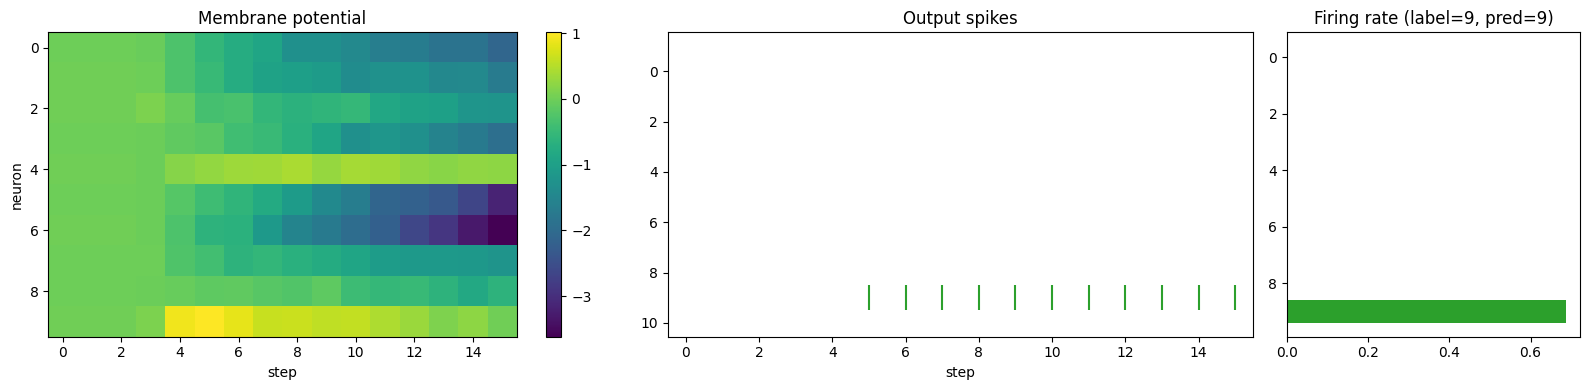

Original label: 9


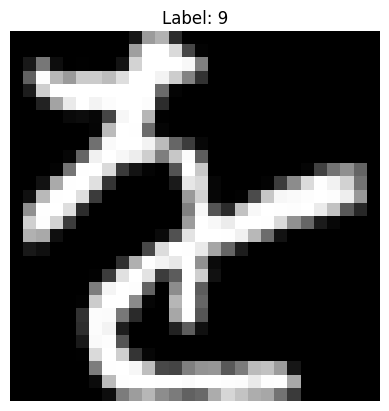

Predicted class (rate coding, T=16): 9


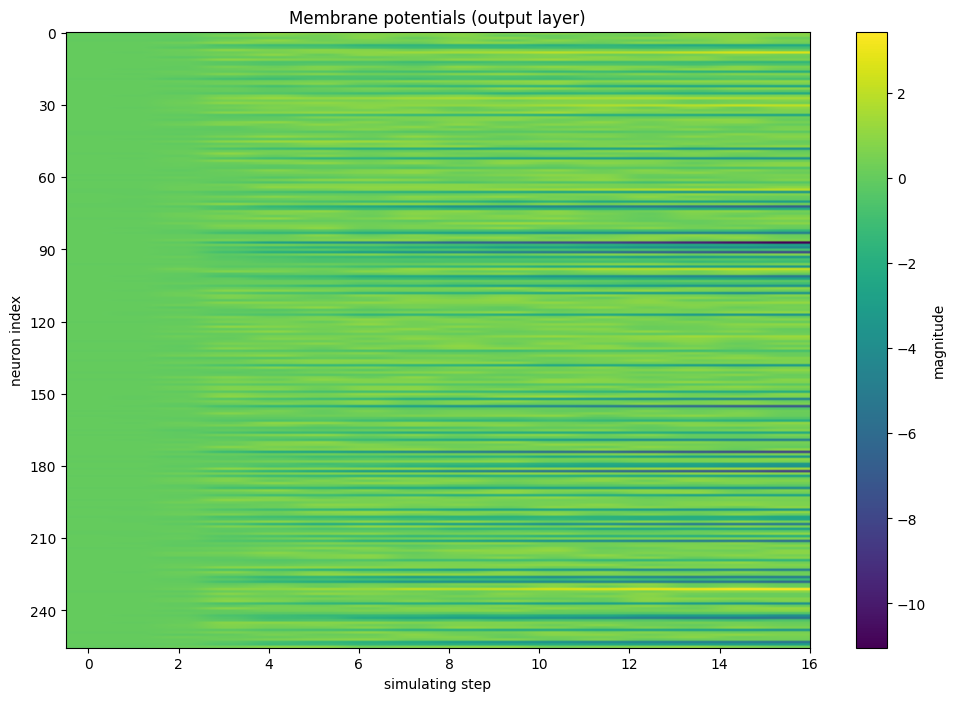

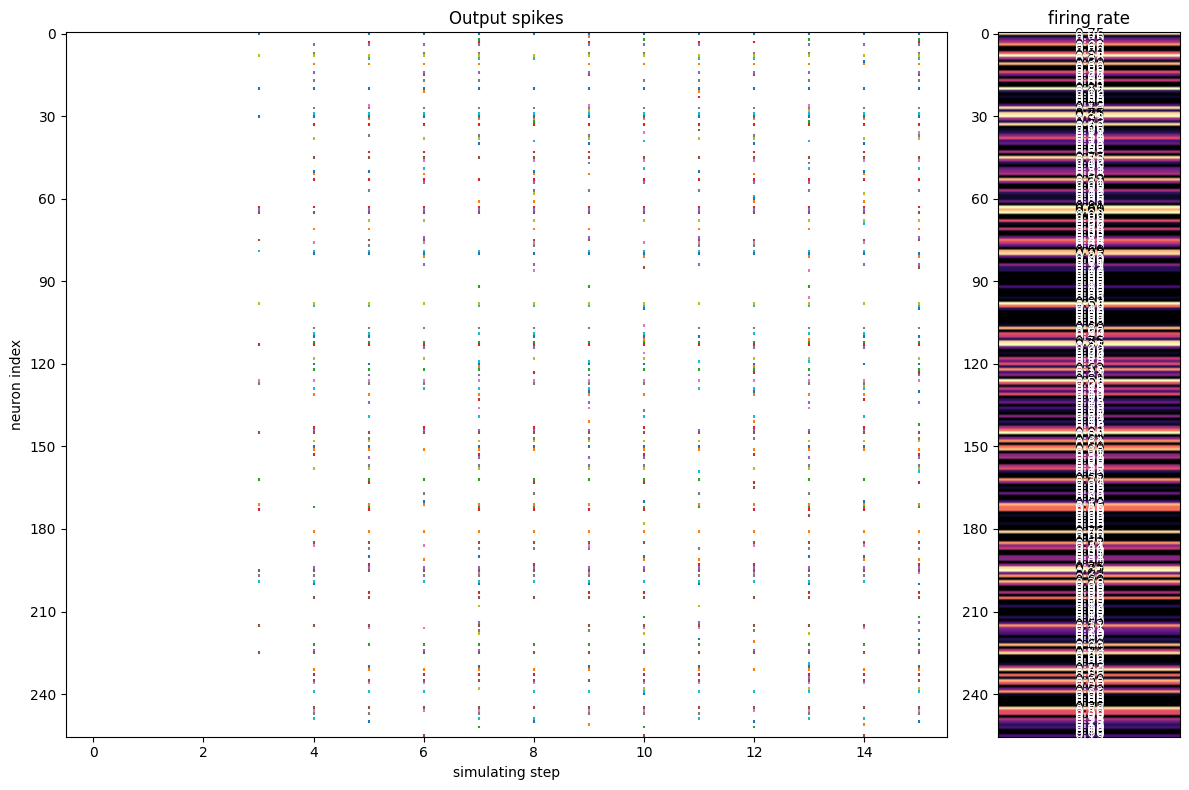

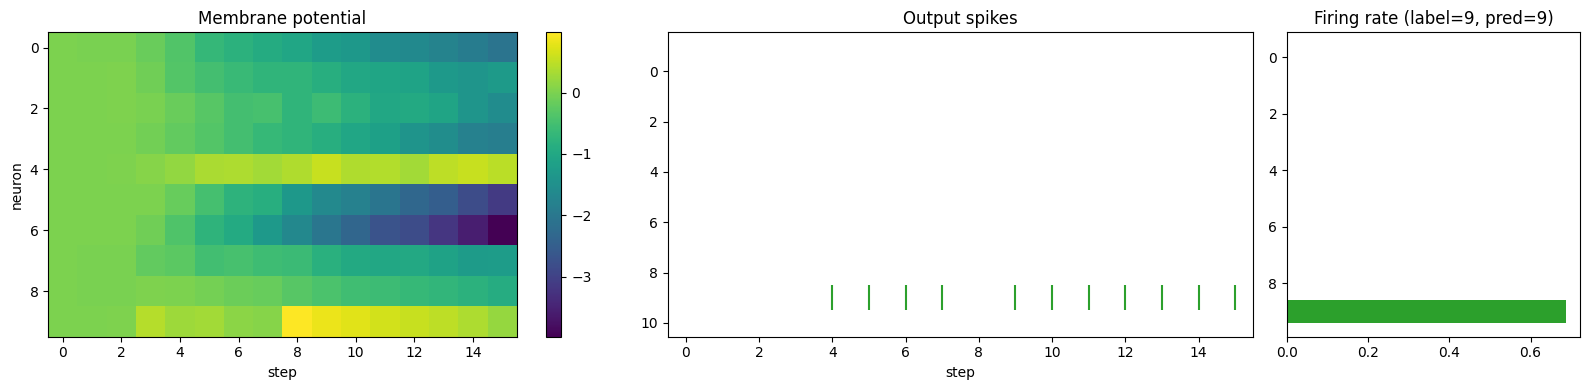

Original label: 9


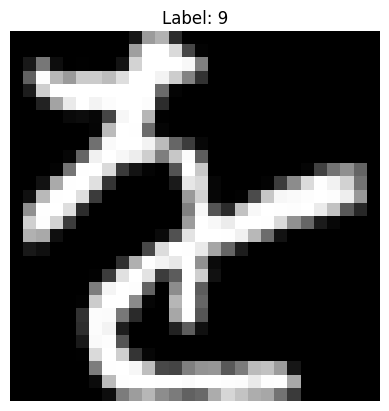

Predicted class (rate coding, T=16): 9


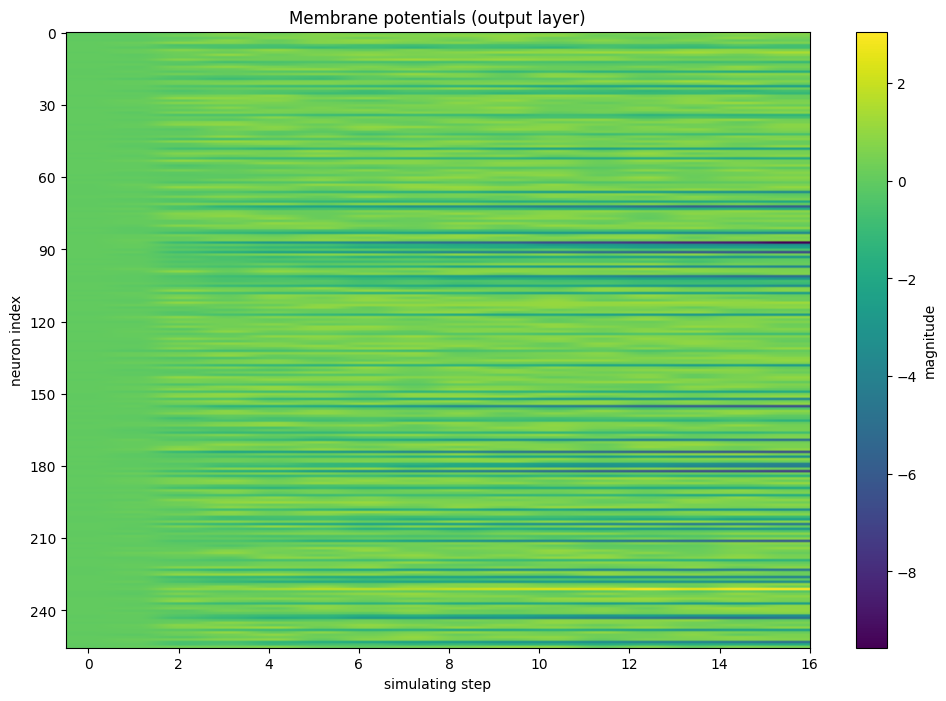

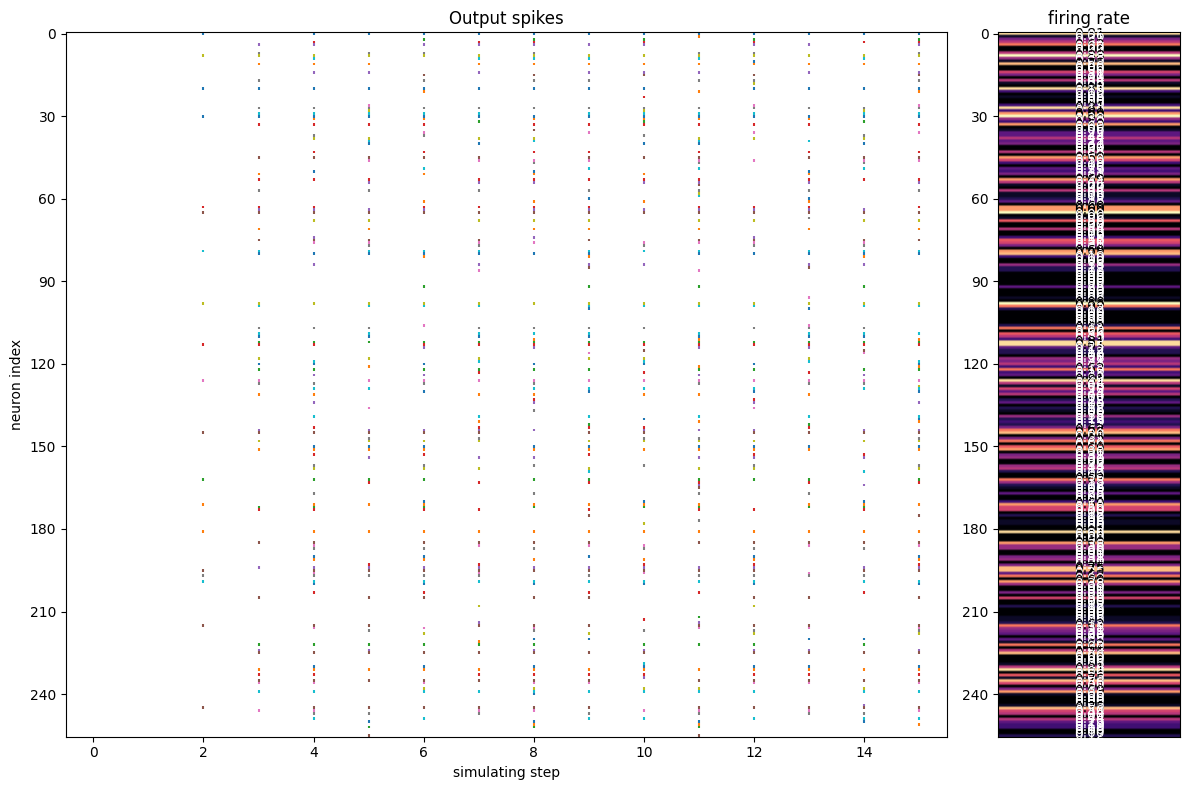

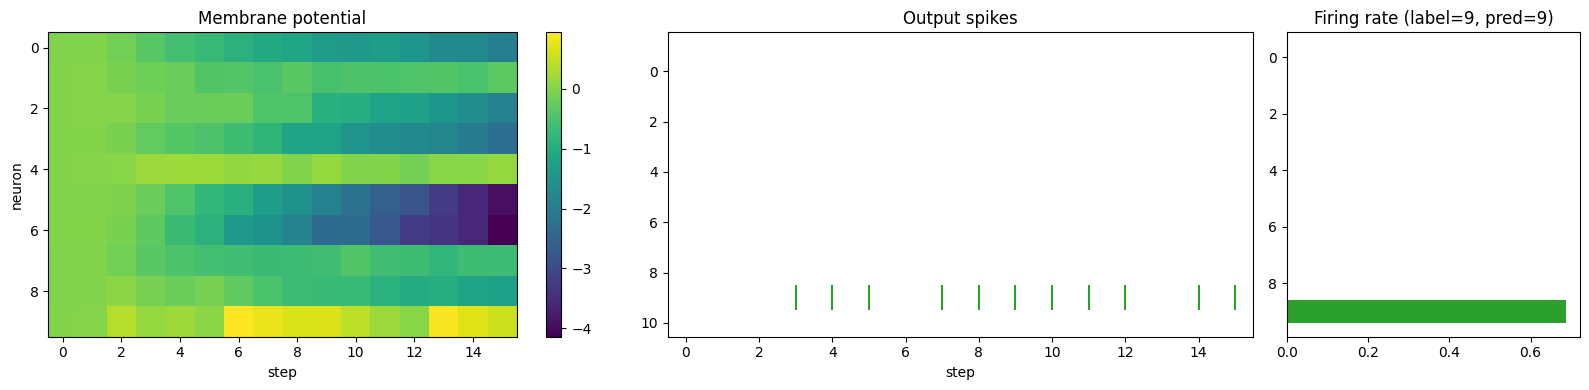

Original label: 9


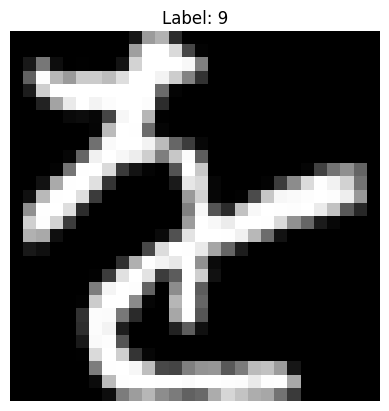

Predicted class (rate coding, T=16): 9


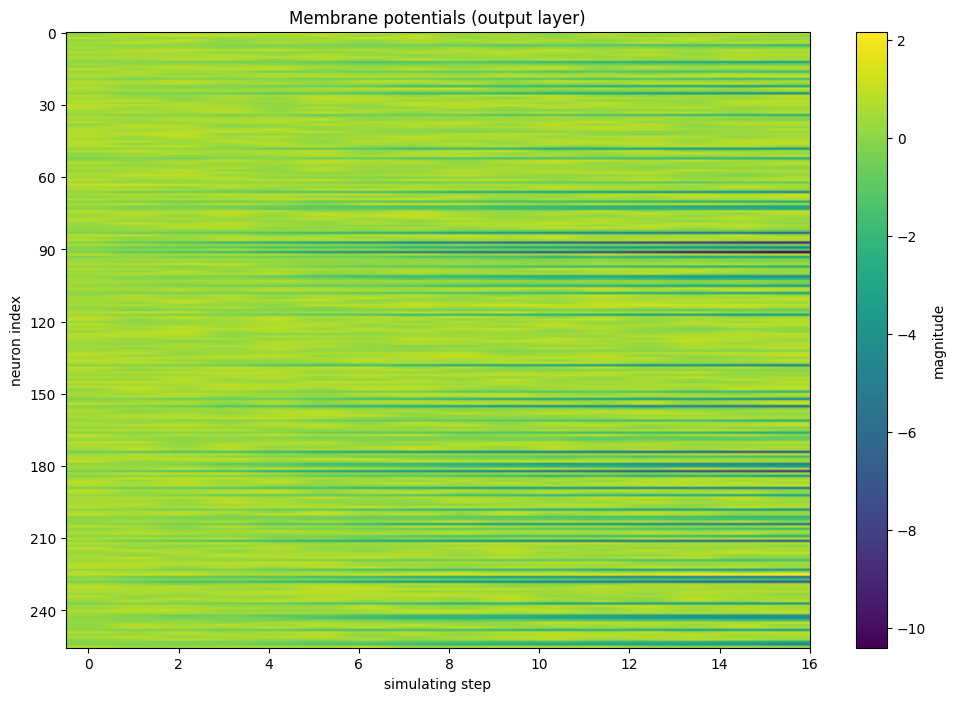

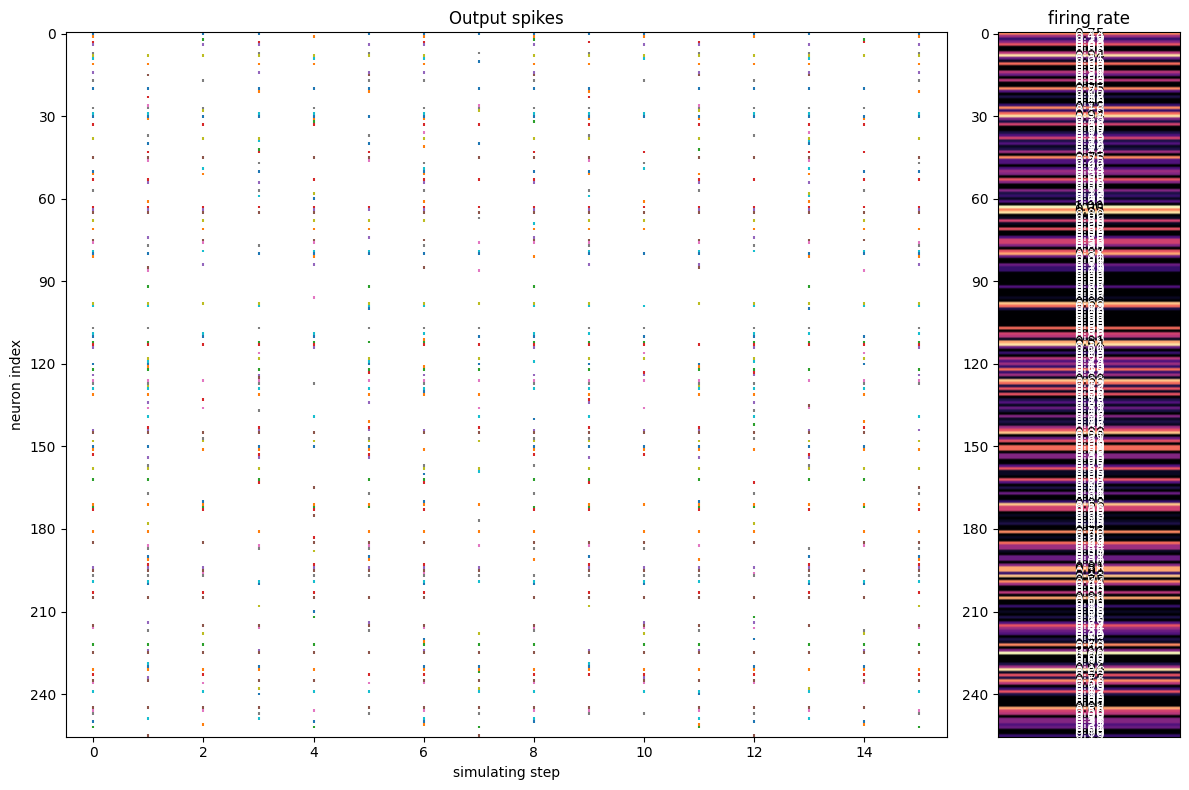

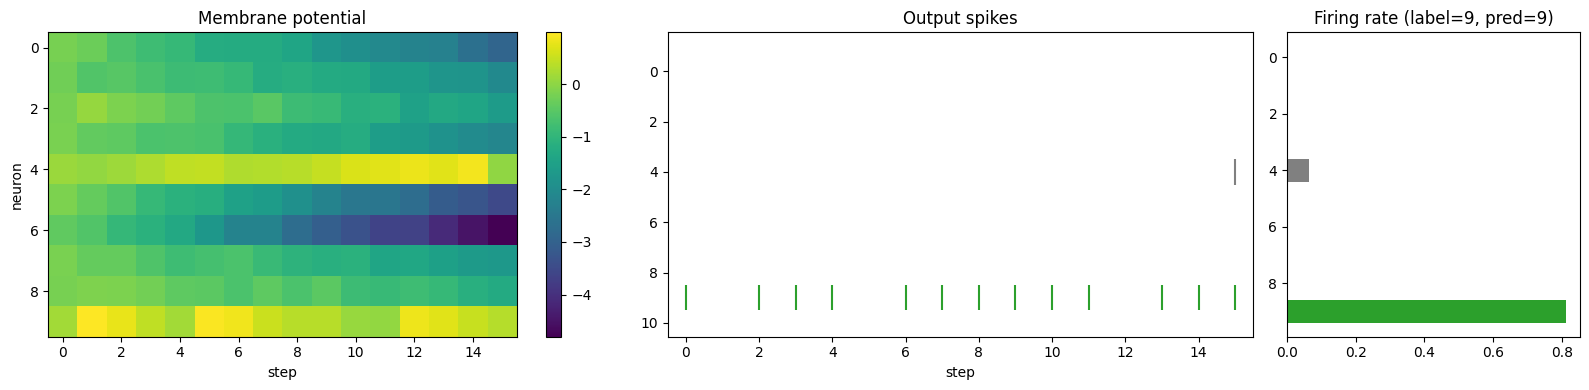

In [74]:
eval_conv_snn.try_visualize_converted(conv_snn_max, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_99, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_half, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_balanced, test_dataset, T=16, index=3373, device=cfg.device)

# Benchmark

In [75]:
from snn_bench.benchmark import Benchmark

In [76]:
import snn_bench.conversion_mod.recipes as snn_bench_recipes

In [77]:
import psutil
import snn_bench.bench.level3 as level3

print("Notebook psutil:", psutil)
print("level3 file:", level3.__file__)
print("level3 has psutil:", hasattr(level3, "psutil"))
print("level3 psutil:", getattr(level3, "psutil", None))


Notebook psutil: <module 'psutil' from '/usr/local/lib/python3.12/dist-packages/psutil/__init__.py'>
level3 file: /usr/local/lib/python3.12/dist-packages/snn_bench/bench/level3.py
level3 has psutil: True
level3 psutil: <module 'psutil' from '/usr/local/lib/python3.12/dist-packages/psutil/__init__.py'>


ANN baseline (int32)
  accuracy        : 0.8992
  MACs            : 5,577,728
  memory ops      : 9,496,916
  E_analytical    : 1.0945e-03 J/sample
    E_mem         : 1.0766e-03 J (98.4%)
    E_ops         : 1.7853e-05 J (1.6%)
    E_addr        : 5.0234e-09 J (0.0%)
  latency         : 0.1551 ms/sample
  GPU (marginal)  : 1.9709e-04 J/sample
  power spread    : 0.3 W across 3 trials

       layer kind     mac      rd    wr      mem_kB  pJ_per_access        E_mem        E_ops      E_total  pct_of_total
  features.0 conv  225792  476672 25088  102.312500      25.670363 1.288036e-05 7.250432e-07 1.360802e-05      1.243330
  features.3 conv 3612672 7237888 12544  145.750000      29.173387 2.115197e-04 1.156180e-05 2.230834e-04     20.382558
classifier.1   fc 1605632 1609280   512 6288.250000     524.536290 8.443943e-04 5.138074e-06 8.495328e-04     77.619629
classifier.4   fc  131072  131840   256  516.000000      59.032258 7.797925e-06 4.194560e-07 8.217458e-06      0.750808
classifier.

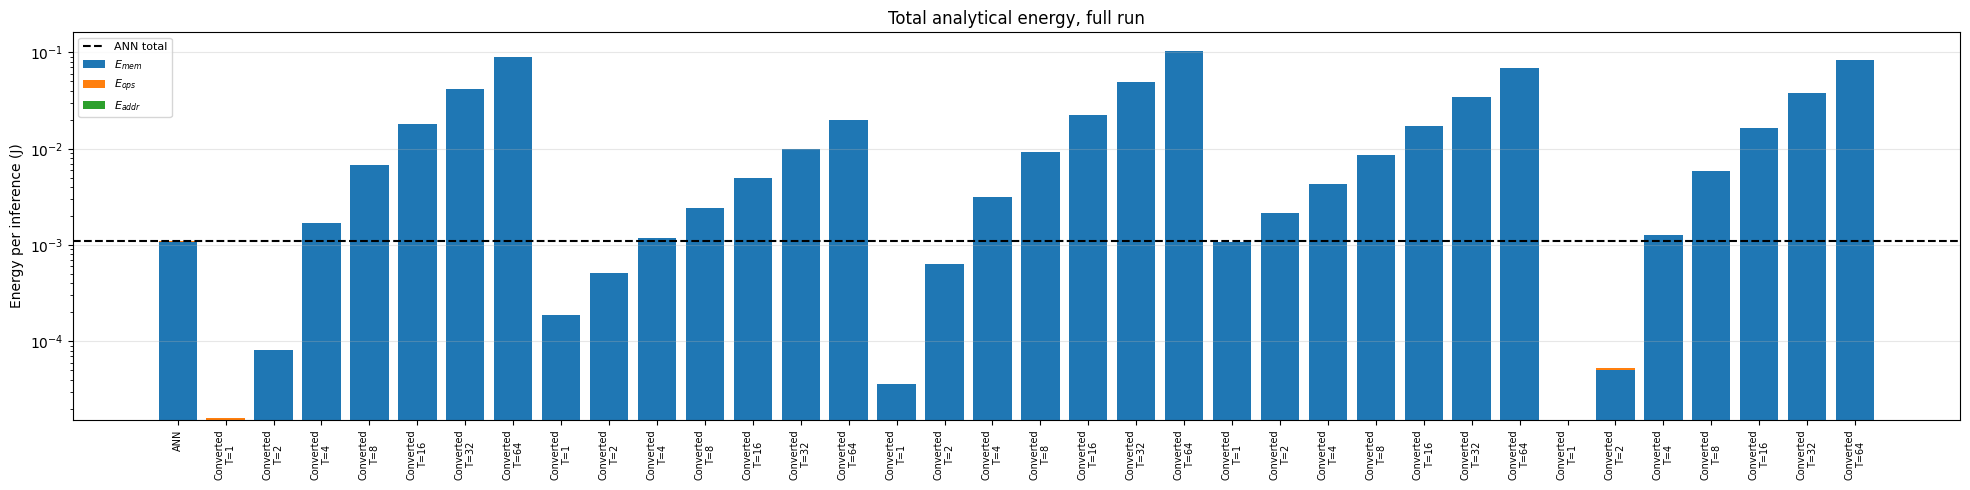

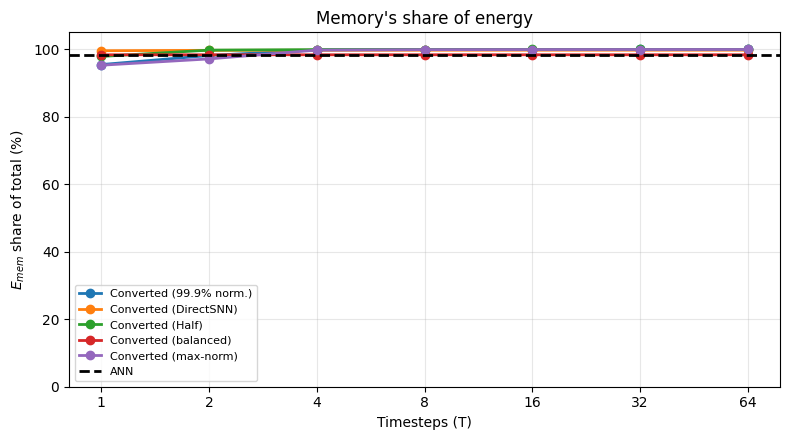

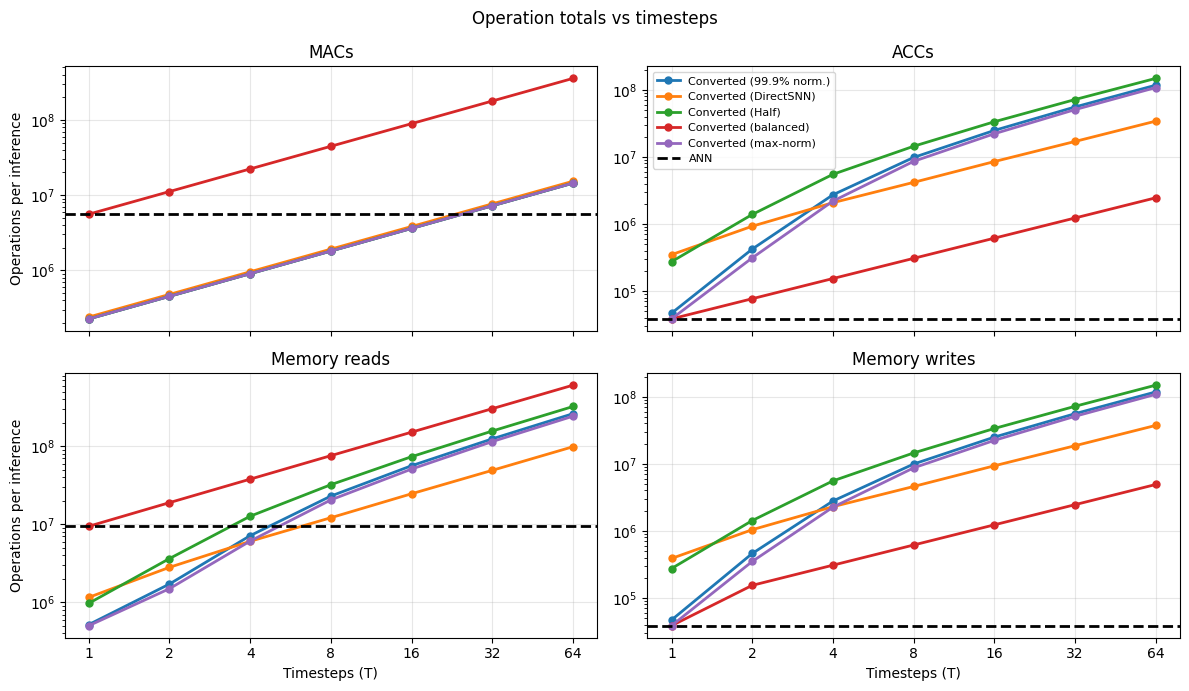

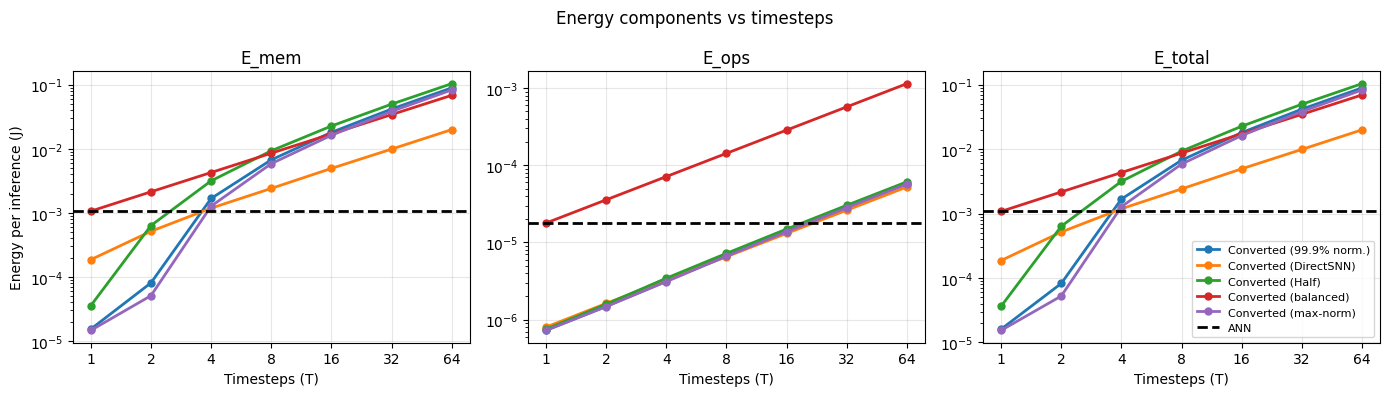

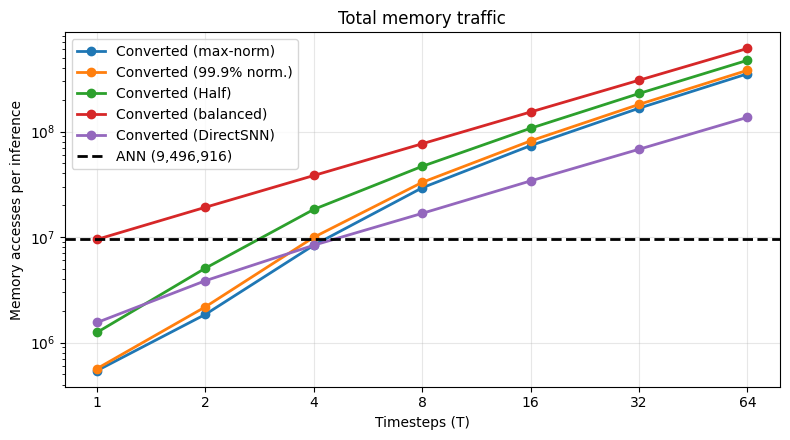

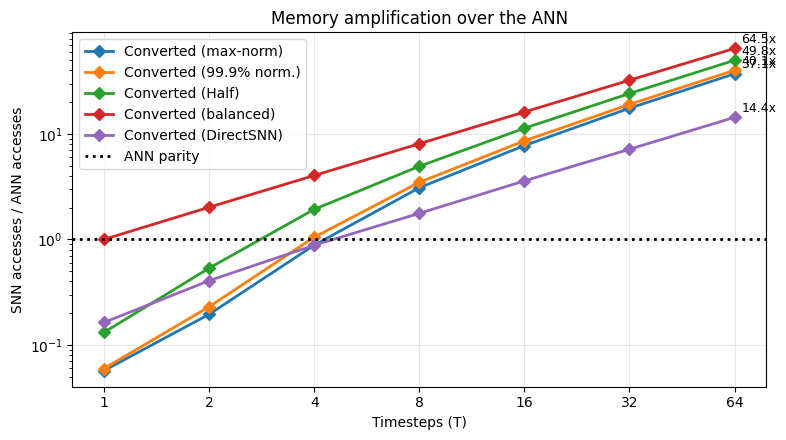

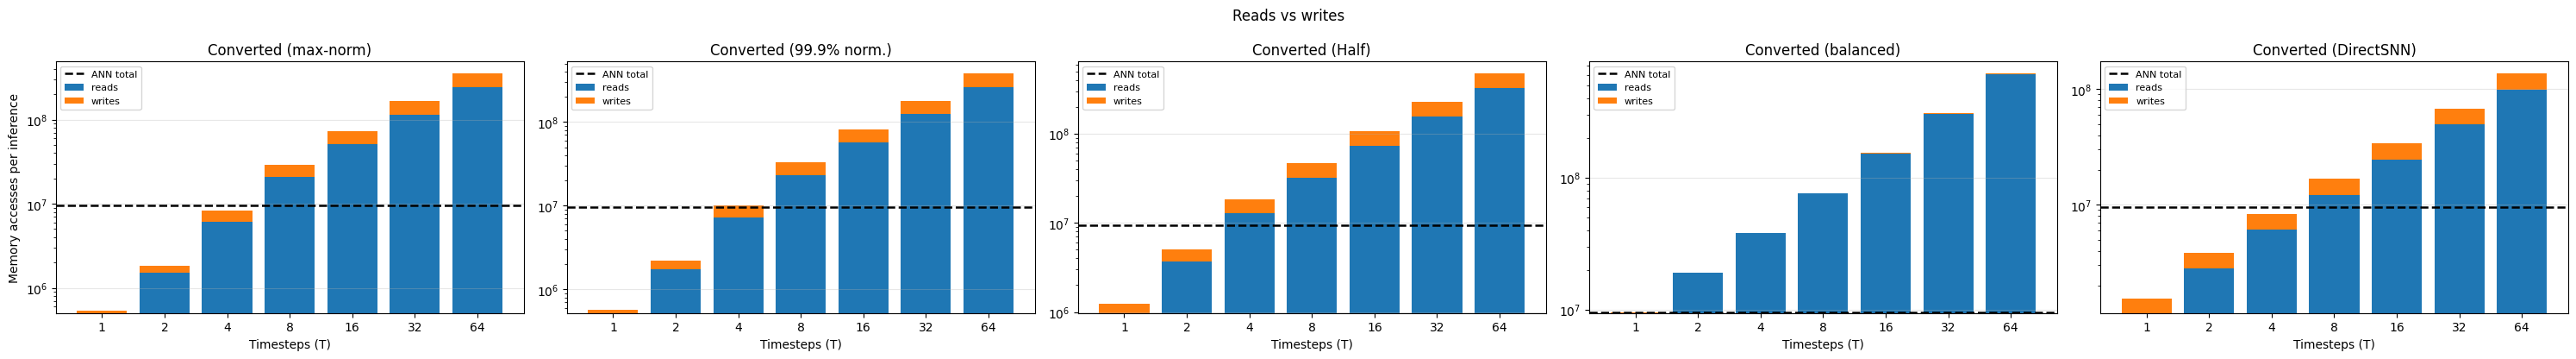

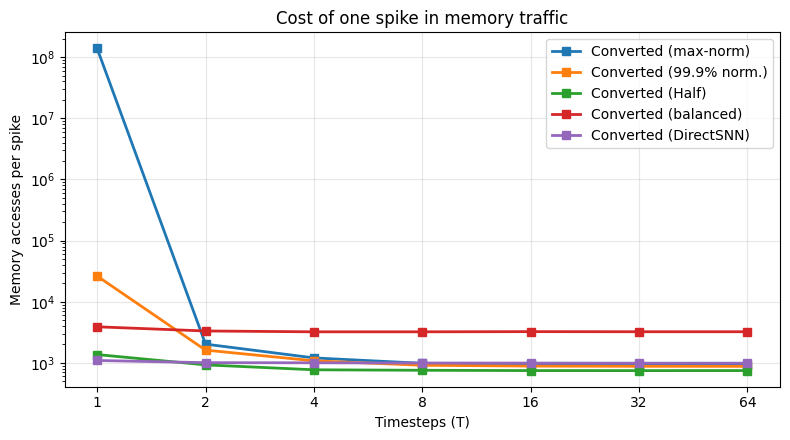

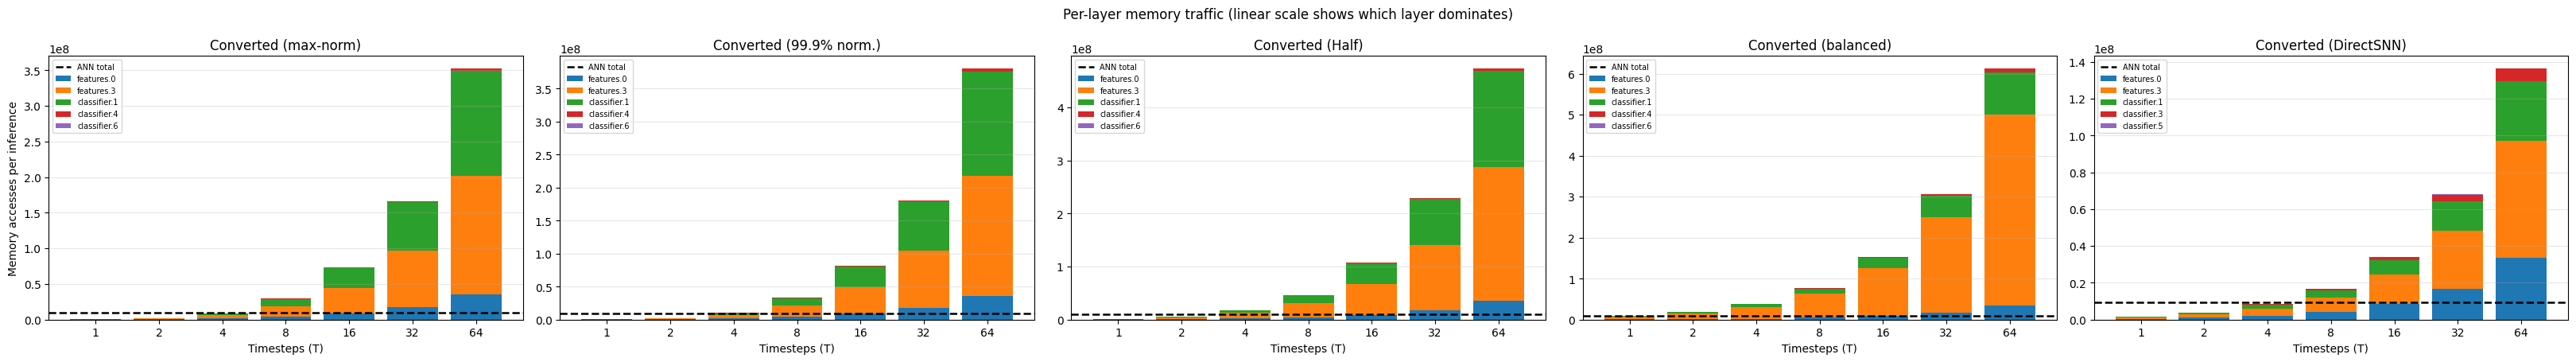

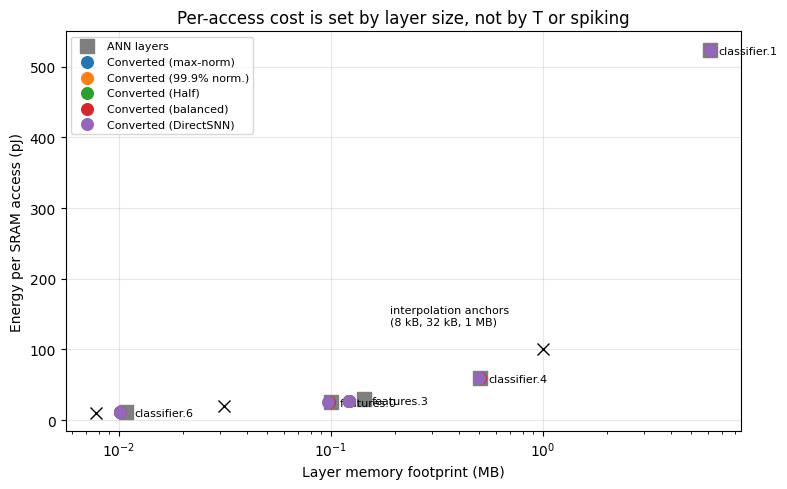

In [78]:
ann_bench_result, totals, snn_models_bench_results = Benchmark.run(ann, {
    "Converted (max-norm)": conv_snn_max,
    "Converted (99.9% norm.)": conv_snn_99,
    "Converted (Half)": conv_snn_half,
    "Converted (balanced)": conv_snn_balanced,
    "Converted (DirectSNN)": snn,
}, test_loader, cfg.device)

In [79]:
ann_bench_result

{'totals': {'E_mem': 0.0010766242669951278,
  'E_ops': 1.78525706e-05,
  'E_addr': 5.023400000000001e-09,
  'E_total': 0.0010944818609951276,
  'mac': 5577728.0,
  'acc': 38410.0,
  'rd': 9458506.0,
  'wr': 38410.0},
 'per_layer':           layer  kind      mac       rd     wr       mem_kB  pJ_per_access  \
 0    features.0  conv   225792   476672  25088   102.312500      25.670363   
 1    features.3  conv  3612672  7237888  12544   145.750000      29.173387   
 2  classifier.1    fc  1605632  1609280    512  6288.250000     524.536290   
 3  classifier.4    fc   131072   131840    256   516.000000      59.032258   
 4  classifier.6    fc     2560     2826     10    11.078125      11.282552   
 
           E_mem         E_ops       E_total  pct_of_total  
 0  1.288036e-05  7.250432e-07  1.360802e-05      1.243330  
 1  2.115197e-04  1.156180e-05  2.230834e-04     20.382558  
 2  8.443943e-04  5.138074e-06  8.495328e-04     77.619629  
 3  7.797925e-06  4.194560e-07  8.217458e-06      

In [80]:
snn_models_bench_results

{'Converted (max-norm)': (    T   total_spikes  total_neurons  spikes_per_neuron  \
  0   1       0.003906          38400       1.017253e-07   
  1   2     912.868359          38400       2.377261e-02   
  2   4    6940.011328          38400       1.807295e-01   
  3   8   29786.197266          38400       7.756822e-01   
  4  16   76970.030469          38400       2.004428e+00   
  5  32  176976.401172          38400       4.608760e+00   
  6  64  376716.197266          38400       9.810318e+00   
  
     spikes_per_neuron_per_step     snn_mac       snn_acc   snn_mem_ops  \
  0                1.017253e-07    225792.0  3.841225e+04  5.417328e+05   
  1                1.188631e-02    451584.0  3.121711e+05  1.850295e+06   
  2                4.518237e-02    903168.0  2.194499e+06  8.368724e+06   
  3                9.696028e-02   1806336.0  8.593517e+06  2.930265e+07   
  4                1.252767e-01   3612672.0  2.218315e+07  7.354101e+07   
  5                1.440238e-01   7225344.0

In [81]:
snn_models_bench_results

{'Converted (max-norm)': (    T   total_spikes  total_neurons  spikes_per_neuron  \
  0   1       0.003906          38400       1.017253e-07   
  1   2     912.868359          38400       2.377261e-02   
  2   4    6940.011328          38400       1.807295e-01   
  3   8   29786.197266          38400       7.756822e-01   
  4  16   76970.030469          38400       2.004428e+00   
  5  32  176976.401172          38400       4.608760e+00   
  6  64  376716.197266          38400       9.810318e+00   
  
     spikes_per_neuron_per_step     snn_mac       snn_acc   snn_mem_ops  \
  0                1.017253e-07    225792.0  3.841225e+04  5.417328e+05   
  1                1.188631e-02    451584.0  3.121711e+05  1.850295e+06   
  2                4.518237e-02    903168.0  2.194499e+06  8.368724e+06   
  3                9.696028e-02   1806336.0  8.593517e+06  2.930265e+07   
  4                1.252767e-01   3612672.0  2.218315e+07  7.354101e+07   
  5                1.440238e-01   7225344.0

In [82]:
from snn_bench.benchmark import BenchLevel 

In [83]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_ONE)


,model,T,accuracy,spikes,neurons,spikes_per_neuron
0,ANN,NaN,0.8992,0.000000,0,NaN
1,Converted (max-norm),1.0,0.0984,0.003906,38400,1.017253e-07
2,Converted (max-norm),2.0,0.0984,912.868359,38400,2.377261e-02
3,Converted (max-norm),4.0,0.2328,6940.011328,38400,1.807295e-01
4,Converted (max-norm),8.0,0.8846,29786.197266,38400,7.756822e-01
5,Converted (max-norm),16.0,0.8738,76970.030469,38400,2.004428e+00
6,Converted (max-norm),32.0,0.8626,176976.401172,38400,4.608760e+00
7,Converted (max-norm),64.0,0.8560,376716.197266,38400,9.810318e+00
8,Converted (99.9% norm.),1.0,0.0984,21.539844,38400,5.609334e-04
9,Converted (99.9% norm.),2.0,0.0984,1348.230078,38400,3.511016e-02


In [84]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_TWO, Ts=[8, 16, 32])


,model,T,accuracy,mac,acc,mem_reads,mem_writes,mem_accesses,accesses_per_mac,accesses_per_spike,mem_amplification,E_mem,E_ops,E_addr,E_total,pct_E_mem,mean_pJ_per_access,E_ratio_ann_over_model
0,ANN,NaN,0.8992,5577728.0,3.841000e+04,9.458506e+06,3.841000e+04,9.496916e+06,1.702650,NaN,1.000000,0.001077,0.000018,5.023400e-09,0.001094,98.368397,113.365672,1.000000
1,Converted (max-norm),8.0,0.8846,1806336.0,8.593517e+06,2.060169e+07,8.700967e+06,2.930265e+07,16.222150,983.766185,3.085492,0.005852,0.000007,9.016785e-07,0.005860,99.871303,199.714781,0.186781
2,Converted (max-norm),16.0,0.8738,3612672.0,2.218315e+07,5.115629e+07,2.238472e+07,7.354101e+07,20.356405,955.449968,7.743673,0.016227,0.000014,2.325706e-06,0.016243,99.900852,220.649706,0.067382
3,Converted (max-norm),32.0,0.8626,7225344.0,5.078514e+07,1.151077e+08,5.117497e+07,1.662827e+08,23.013806,939.575372,17.509123,0.038276,0.000028,5.322759e-06,0.038309,99.912496,230.185991,0.028569
4,Converted (99.9% norm.),8.0,0.8836,1806336.0,9.826336e+06,2.306348e+07,9.933786e+06,3.299727e+07,18.267513,913.480747,3.474524,0.006712,0.000007,1.032284e-06,0.006720,99.884005,203.425569,0.162862
5,Converted (99.9% norm.),16.0,0.8646,3612672.0,2.485507e+07,5.649079e+07,2.505664e+07,8.154743e+07,22.572610,886.608873,8.586728,0.018038,0.000014,2.609086e-06,0.018055,99.907753,221.200530,0.060619
6,Converted (99.9% norm.),32.0,0.8514,7225344.0,5.561018e+07,1.247378e+08,5.600002e+07,1.807378e+08,25.014422,879.749549,19.031210,0.041605,0.000029,5.833752e-06,0.041639,99.917107,230.193267,0.026285
7,Converted (Half),8.0,0.8678,1806336.0,1.442958e+07,3.226254e+07,1.453703e+07,4.679958e+07,25.908566,757.043600,4.927871,0.009290,0.000007,1.526471e-06,0.009298,99.905902,198.500687,0.117705
8,Converted (Half),16.0,0.8314,3612672.0,3.347583e+07,7.371781e+07,3.367741e+07,1.073952e+08,29.727363,748.236649,11.308430,0.022626,0.000015,3.536703e-06,0.022645,99.918547,210.682487,0.048333
9,Converted (Half),32.0,0.7940,7225344.0,7.177929e+07,1.570495e+08,7.216912e+07,2.292187e+08,31.724255,747.431513,24.136115,0.049612,0.000030,7.578383e-06,0.049650,99.923711,216.440009,0.022044


In [85]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_THREE, models="Converted (max-norm)")


,model,T,accuracy,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,ANN,NaN,0.8992,0.155141,0.005174,0.000197,33.308718,0.309175,32.039825,124.245605,54.7,nvml_energy_counter
1,Converted (max-norm),1.0,0.0984,0.157199,0.005440,0.000456,34.591079,0.200736,31.690722,160.411621,56.1,nvml_energy_counter
2,Converted (max-norm),2.0,0.0984,0.162921,0.006164,0.000982,37.786540,0.306804,31.768421,166.911621,57.8,nvml_energy_counter
3,Converted (max-norm),4.0,0.2328,0.172671,0.010362,0.004919,59.919184,1.474357,31.477227,166.911621,61.8,nvml_energy_counter
4,Converted (max-norm),8.0,0.8846,0.191194,0.012000,0.006111,62.762988,0.290785,30.802938,166.911621,65.5,nvml_energy_counter
5,Converted (max-norm),16.0,0.8738,0.316375,0.020420,0.010424,64.570903,0.187400,31.599244,166.911621,48.2,nvml_energy_counter
6,Converted (max-norm),32.0,0.8626,0.613435,0.039730,0.020406,64.766680,0.880543,31.502051,166.911621,37.4,nvml_energy_counter
7,Converted (max-norm),64.0,0.8560,1.199800,0.078273,0.040482,65.336837,0.589004,31.498557,166.911621,32.0,nvml_energy_counter


In [86]:
Benchmark.query_levels(totals, [BenchLevel.LEVEL_ONE, BenchLevel.LEVEL_THREE])


,model,T,accuracy,spikes,neurons,spikes_per_neuron,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,ANN,NaN,0.8992,0.000000,0,NaN,0.155141,0.005174,0.000197,33.308718,0.309175,32.039825,124.245605,54.7,nvml_energy_counter
1,Converted (max-norm),1.0,0.0984,0.003906,38400,1.017253e-07,0.157199,0.005440,0.000456,34.591079,0.200736,31.690722,160.411621,56.1,nvml_energy_counter
2,Converted (max-norm),2.0,0.0984,912.868359,38400,2.377261e-02,0.162921,0.006164,0.000982,37.786540,0.306804,31.768421,166.911621,57.8,nvml_energy_counter
3,Converted (max-norm),4.0,0.2328,6940.011328,38400,1.807295e-01,0.172671,0.010362,0.004919,59.919184,1.474357,31.477227,166.911621,61.8,nvml_energy_counter
4,Converted (max-norm),8.0,0.8846,29786.197266,38400,7.756822e-01,0.191194,0.012000,0.006111,62.762988,0.290785,30.802938,166.911621,65.5,nvml_energy_counter
5,Converted (max-norm),16.0,0.8738,76970.030469,38400,2.004428e+00,0.316375,0.020420,0.010424,64.570903,0.187400,31.599244,166.911621,48.2,nvml_energy_counter
6,Converted (max-norm),32.0,0.8626,176976.401172,38400,4.608760e+00,0.613435,0.039730,0.020406,64.766680,0.880543,31.502051,166.911621,37.4,nvml_energy_counter
7,Converted (max-norm),64.0,0.8560,376716.197266,38400,9.810318e+00,1.199800,0.078273,0.040482,65.336837,0.589004,31.498557,166.911621,32.0,nvml_energy_counter
8,Converted (99.9% norm.),1.0,0.0984,21.539844,38400,5.609334e-04,0.154898,0.005323,0.000460,34.406555,0.254631,31.441588,160.265137,56.3,nvml_energy_counter
9,Converted (99.9% norm.),2.0,0.0984,1348.230078,38400,3.511016e-02,0.160670,0.006049,0.000986,37.708814,0.245105,31.564556,166.765137,58.1,nvml_energy_counter


In [87]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_ALL, include_ann=False)

,model,T,accuracy,spikes,neurons,spikes_per_neuron,mac,acc,mem_reads,mem_writes,...,E_ratio_ann_over_model,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,Converted (max-norm),1.0,0.0984,0.003906,38400,1.017253e-07,225792.0,3.841225e+04,5.033205e+05,3.841225e+04,...,71.145012,0.157199,0.005440,0.000456,34.591079,0.200736,31.690722,160.411621,56.1,nvml_energy_counter
1,Converted (max-norm),2.0,0.0984,912.868359,38400,2.377261e-02,451584.0,3.121711e+05,1.501270e+06,3.490251e+05,...,20.849820,0.162921,0.006164,0.000982,37.786540,0.306804,31.768421,166.911621,57.8,nvml_energy_counter
2,Converted (max-norm),4.0,0.2328,6940.011328,38400,1.807295e-01,903168.0,2.194499e+06,6.113838e+06,2.254885e+06,...,0.858270,0.172671,0.010362,0.004919,59.919184,1.474357,31.477227,166.911621,61.8,nvml_energy_counter
3,Converted (max-norm),8.0,0.8846,29786.197266,38400,7.756822e-01,1806336.0,8.593517e+06,2.060169e+07,8.700967e+06,...,0.186781,0.191194,0.012000,0.006111,62.762988,0.290785,30.802938,166.911621,65.5,nvml_energy_counter
4,Converted (max-norm),16.0,0.8738,76970.030469,38400,2.004428e+00,3612672.0,2.218315e+07,5.115629e+07,2.238472e+07,...,0.067382,0.316375,0.020420,0.010424,64.570903,0.187400,31.599244,166.911621,48.2,nvml_energy_counter
5,Converted (max-norm),32.0,0.8626,176976.401172,38400,4.608760e+00,7225344.0,5.078514e+07,1.151077e+08,5.117497e+07,...,0.028569,0.613435,0.039730,0.020406,64.766680,0.880543,31.502051,166.911621,37.4,nvml_energy_counter
6,Converted (max-norm),64.0,0.8560,376716.197266,38400,9.810318e+00,14450688.0,1.082063e+08,2.434441e+08,1.089726e+08,...,0.013231,1.199800,0.078273,0.040482,65.336837,0.589004,31.498557,166.911621,32.0,nvml_energy_counter
7,Converted (99.9% norm.),1.0,0.0984,21.539844,38400,5.609334e-04,225792.0,4.669495e+04,5.199003e+05,4.669495e+04,...,68.116025,0.154898,0.005323,0.000460,34.406555,0.254631,31.441588,160.265137,56.3,nvml_energy_counter
8,Converted (99.9% norm.),2.0,0.0984,1348.230078,38400,3.511016e-02,451584.0,4.222274e+05,1.721496e+06,4.590814e+05,...,13.302673,0.160670,0.006049,0.000986,37.708814,0.245105,31.564556,166.765137,58.1,nvml_energy_counter
9,Converted (99.9% norm.),4.0,0.6630,9208.933203,38400,2.398160e-01,903168.0,2.724960e+06,7.173410e+06,2.785346e+06,...,0.651884,0.170727,0.010246,0.004816,60.108044,1.531543,31.855005,166.765137,61.5,nvml_energy_counter


                  model    T  accuracy  baseline_accuracy  retention  retention_pct   delta_pp  delta_rel_pct          label
   Converted (max-norm)  1.0    0.0984             0.8992   0.109431      10.943060 -80.080002     -89.056940 0.11x (-89.1%)
   Converted (max-norm)  2.0    0.0984             0.8992   0.109431      10.943060 -80.080002     -89.056940 0.11x (-89.1%)
   Converted (max-norm)  4.0    0.2328             0.8992   0.258897      25.889679 -66.640002     -74.110321 0.26x (-74.1%)
   Converted (max-norm)  8.0    0.8846             0.8992   0.983763      98.376332  -1.460002      -1.623668  0.98x (-1.6%)
   Converted (max-norm) 16.0    0.8738             0.8992   0.971753      97.175265  -2.540002      -2.824735  0.97x (-2.8%)
   Converted (max-norm) 32.0    0.8626             0.8992   0.959297      95.929713  -3.660002      -4.070287  0.96x (-4.1%)
   Converted (max-norm) 64.0    0.8560             0.8992   0.951957      95.195727  -4.320002      -4.804273  0.95x (-4.8%)


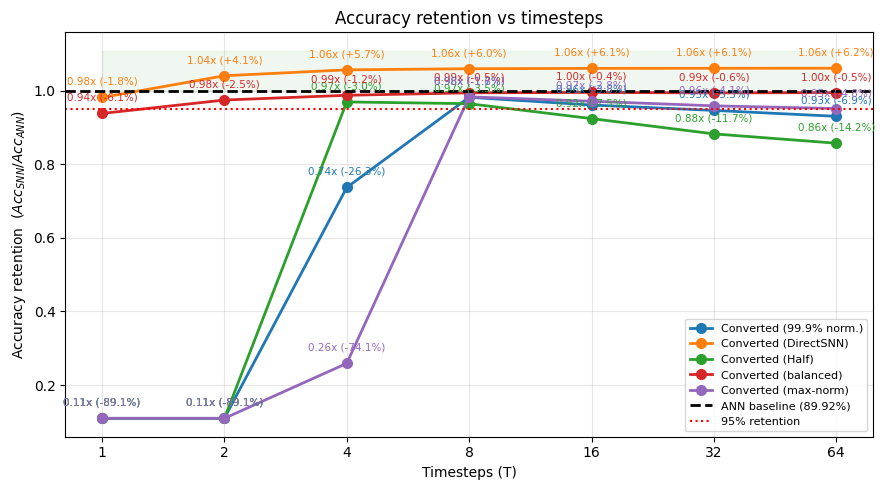

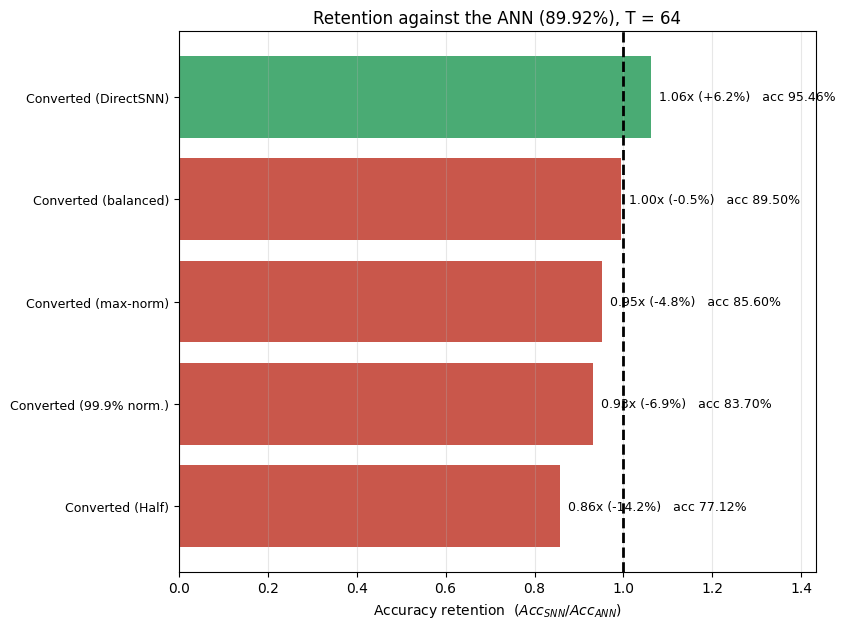

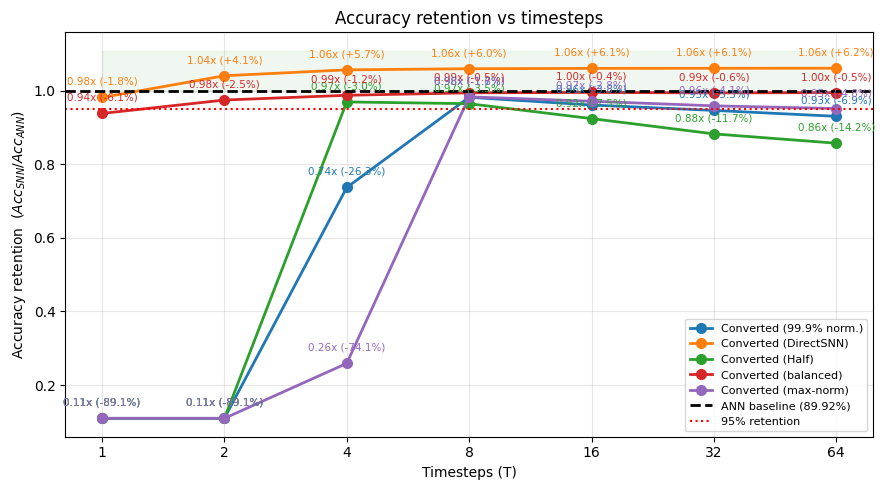

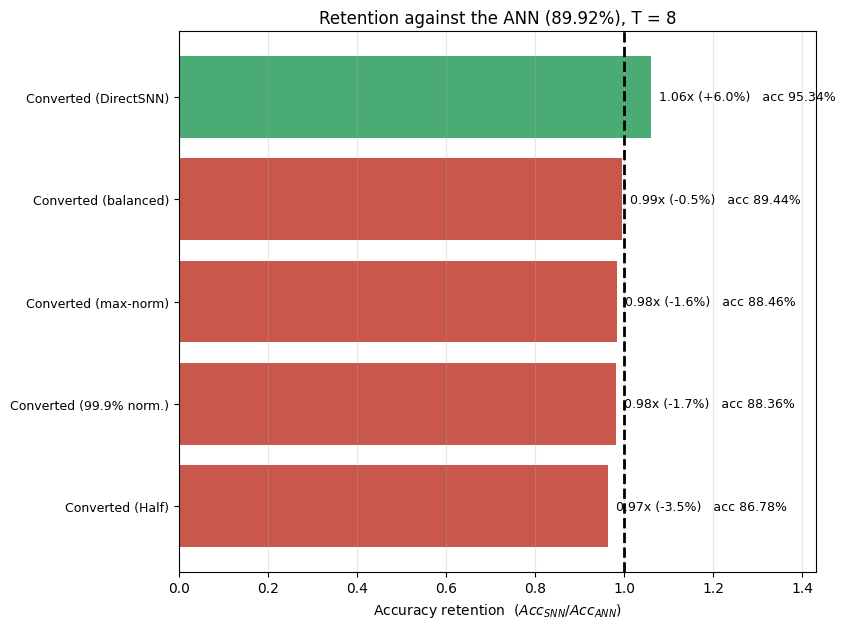

In [88]:
ret = Benchmark.accuracy_retention(
    ann_results['ANN'].accuracy,  # baseline accuracy as a float
    {
        "Converted (max-norm)": conv_snn_max,
        "Converted (99.9% norm.)": conv_snn_99,
        "Converted (Half)": conv_snn_half,
        "Converted (balanced)": conv_snn_balanced,
        "Converted (DirectSNN)": snn,
    },    # the model itself
    loader=test_loader, device=cfg.device,
    Ts=[1, 2, 4, 8, 16, 32, 64],
)

print(ret.to_string(index=False))
print(Benchmark.best_retention(ret).to_string(index=False))

Benchmark.plot_accuracy_retention(ret)                 # picks the best T for the bar chart
Benchmark.plot_accuracy_retention(ret, at_T=8)         # or force one

In [89]:
snn_models_bench_results['Converted (max-norm)'][0]

,T,total_spikes,total_neurons,spikes_per_neuron,spikes_per_neuron_per_step,snn_mac,snn_acc,snn_mem_ops,ann_mac,ann_mem_ops,...,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,energy_source,cpu_util_pct,gpu_peak_mem_MB,accuracy,acc_per_joule_raw,acc_per_joule
0,1,0.003906,38400,1.017253e-07,1.017253e-07,225792.0,3.841225e+04,5.417328e+05,5577728.0,9496916.0,...,0.005440,0.000456,34.591079,0.200736,nvml_energy_counter,56.1,160.411621,0.0984,6396.331812,NaN
1,2,912.868359,38400,2.377261e-02,1.188631e-02,451584.0,3.121711e+05,1.850295e+06,5577728.0,9496916.0,...,0.006164,0.000982,37.786540,0.306804,nvml_energy_counter,57.8,166.911621,0.0984,1874.514656,NaN
2,4,6940.011328,38400,1.807295e-01,4.518237e-02,903168.0,2.194499e+06,8.368724e+06,5577728.0,9496916.0,...,0.010362,0.004919,59.919184,1.474357,nvml_energy_counter,61.8,166.911621,0.2328,182.556834,NaN
3,8,29786.197266,38400,7.756822e-01,9.696028e-02,1806336.0,8.593517e+06,2.930265e+07,5577728.0,9496916.0,...,0.012000,0.006111,62.762988,0.290785,nvml_energy_counter,65.5,166.911621,0.8846,150.962989,133.897311
4,16,76970.030469,38400,2.004428e+00,1.252767e-01,3612672.0,2.218315e+07,7.354101e+07,5577728.0,9496916.0,...,0.020420,0.010424,64.570903,0.187400,nvml_energy_counter,48.2,166.911621,0.8738,53.795787,47.639254
5,32,176976.401172,38400,4.608760e+00,1.440238e-01,7225344.0,5.078514e+07,1.662827e+08,5577728.0,9496916.0,...,0.039730,0.020406,64.766680,0.880543,nvml_energy_counter,37.4,166.911621,0.8626,22.516630,19.906309
6,64,376716.197266,38400,9.810318e+00,1.532862e-01,14450688.0,1.082063e+08,3.524168e+08,5577728.0,9496916.0,...,0.078273,0.040482,65.336837,0.589004,nvml_energy_counter,32.0,166.911621,0.8560,10.348362,9.139441


In [92]:
snn_eff = Benchmark.calculate_energy_efficiency_from_summary(snn_models_bench_results['Converted (max-norm)'][0], n_classes=NUM_CLASSES, min_accuracy=0.5)

In [93]:
snn_eff

,T,accuracy,E_joules,eff_raw,eff_above_chance
0,1,0.0984,0.000015,6396.331812,NaN
1,2,0.0984,0.000052,1874.514656,NaN
2,4,0.2328,0.001275,182.556834,NaN
3,8,0.8846,0.005860,150.962989,133.897311
4,16,0.8738,0.016243,53.795787,47.639254
5,32,0.8626,0.038309,22.516630,19.906309
6,64,0.8560,0.082718,10.348362,9.139441


In [94]:
ann_bench_result

{'totals': {'E_mem': 0.0010766242669951278,
  'E_ops': 1.78525706e-05,
  'E_addr': 5.023400000000001e-09,
  'E_total': 0.0010944818609951276,
  'mac': 5577728.0,
  'acc': 38410.0,
  'rd': 9458506.0,
  'wr': 38410.0},
 'per_layer':           layer  kind      mac       rd     wr       mem_kB  pJ_per_access  \
 0    features.0  conv   225792   476672  25088   102.312500      25.670363   
 1    features.3  conv  3612672  7237888  12544   145.750000      29.173387   
 2  classifier.1    fc  1605632  1609280    512  6288.250000     524.536290   
 3  classifier.4    fc   131072   131840    256   516.000000      59.032258   
 4  classifier.6    fc     2560     2826     10    11.078125      11.282552   
 
           E_mem         E_ops       E_total  pct_of_total  
 0  1.288036e-05  7.250432e-07  1.360802e-05      1.243330  
 1  2.115197e-04  1.156180e-05  2.230834e-04     20.382558  
 2  8.443943e-04  5.138074e-06  8.495328e-04     77.619629  
 3  7.797925e-06  4.194560e-07  8.217458e-06      

In [95]:
ann_eff = Benchmark.calculate_energy_efficiency(ann_bench_result['accuracy'], ann_bench_result['totals']['E_total'])

In [96]:
ann_eff

821.5759731115388

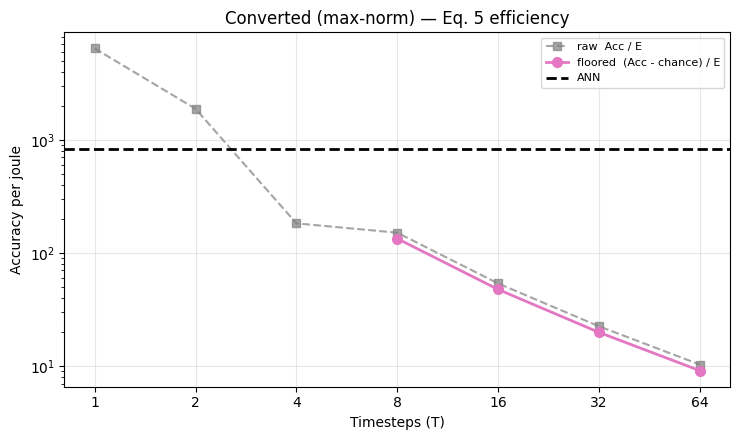

In [97]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (max-norm)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)a
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (max-norm) — ")

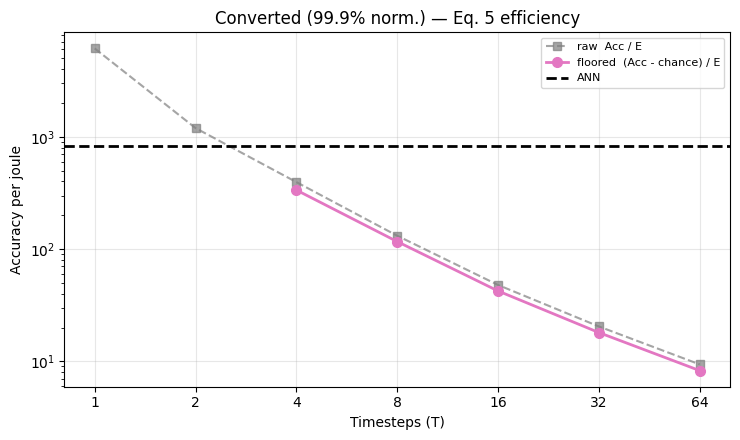

In [122]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (99.9% norm.)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (99.9% norm.) — ")

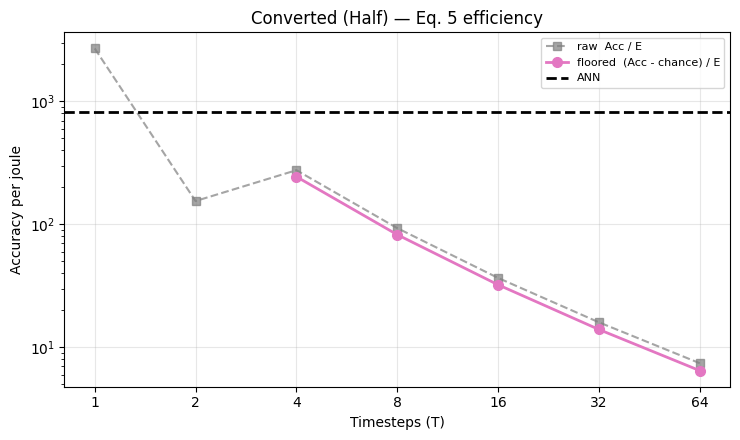

In [123]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (Half)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (Half) — ")

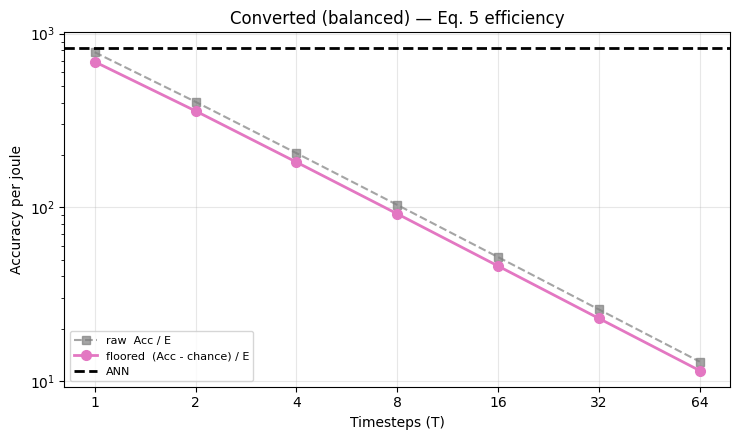

In [124]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (balanced)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (balanced) — ")

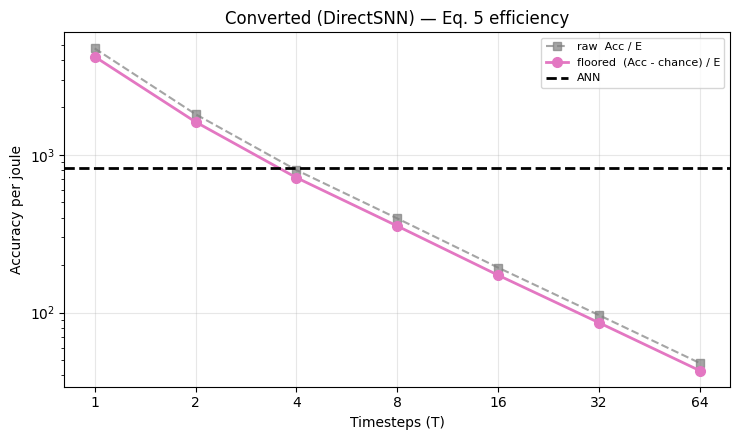

In [125]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (DirectSNN)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (DirectSNN) — ")

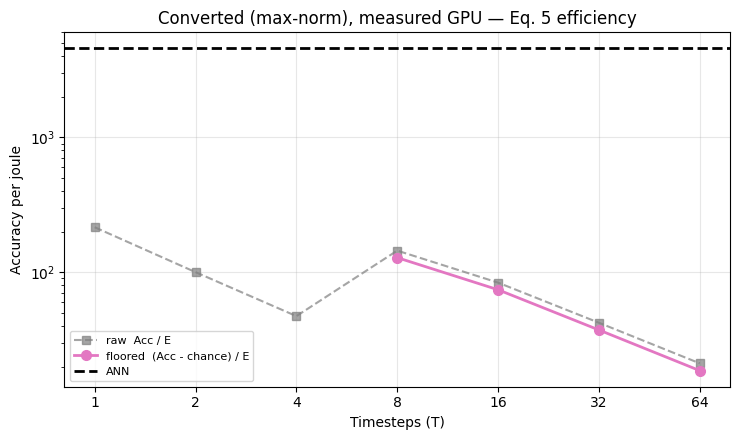

In [100]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (max-norm)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (max-norm), measured GPU — ")

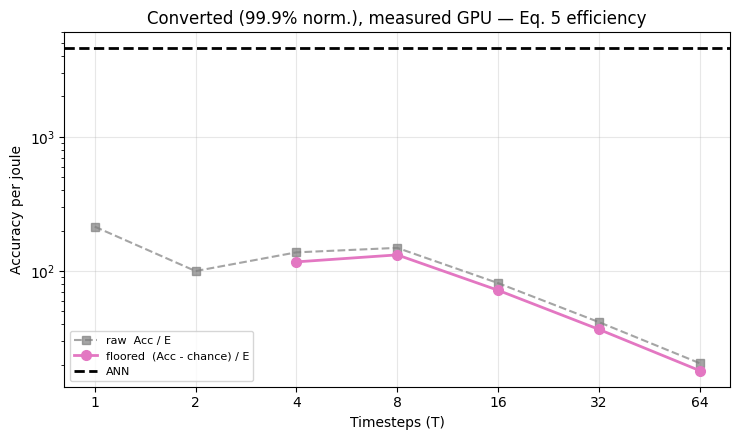

In [115]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (99.9% norm.)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (99.9% norm.), measured GPU — ")

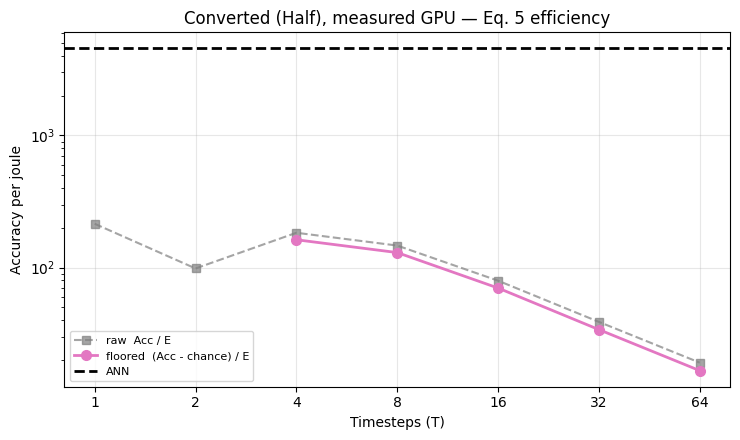

In [118]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (Half)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (Half), measured GPU — ")

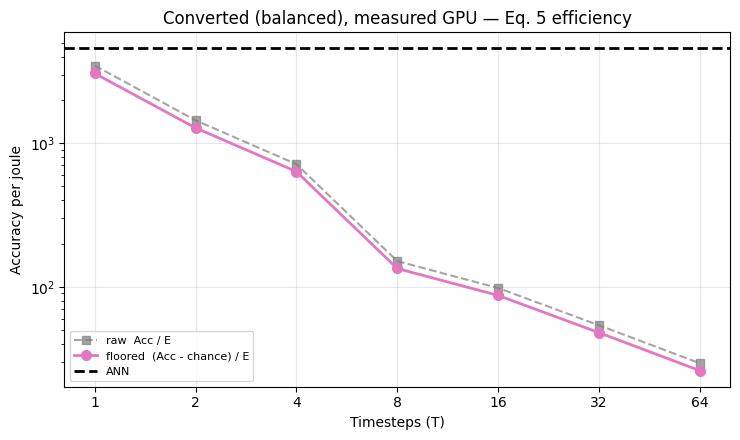

In [119]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (balanced)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (balanced), measured GPU — ")

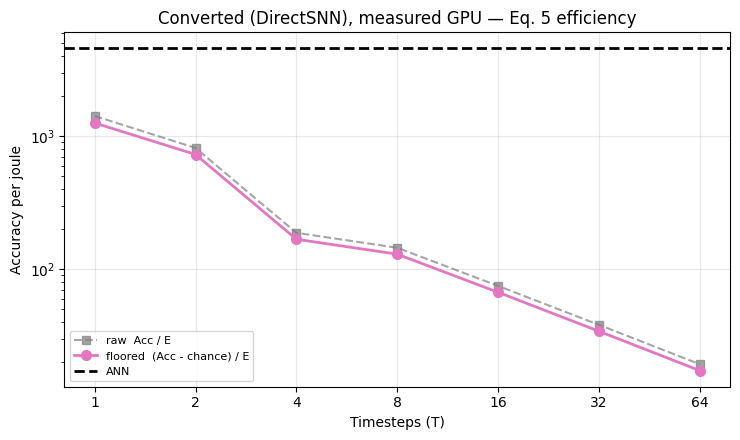

In [120]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (DirectSNN)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (DirectSNN), measured GPU — ")

In [131]:
from pathlib import Path
filepath_l1 = Path("results/level_one.csv")
filepath_l2 = Path("results/level_two.csv")
filepath_l3 = Path("results/level_thee.csv")
filepath_l1.parent.mkdir(parents=True, exist_ok=True)
filepath_l2.parent.mkdir(parents=True, exist_ok=True)
filepath_l3.parent.mkdir(parents=True, exist_ok=True)

In [133]:
l1 = Benchmark.query_levels(totals, BenchLevel.LEVEL_ONE)
l1.to_csv(filepath_l1)

In [134]:
l2 = Benchmark.query_levels(totals, BenchLevel.LEVEL_TWO)
l2.to_csv(filepath_l2)

In [135]:
l3 = Benchmark.query_levels(totals, BenchLevel.LEVEL_THREE)
l3.to_csv(filepath_l3)